## 4.1 常用技巧

### 4.1.1 导入 简写

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt # 最常用的接口
import numpy as np
from seaborn import violinplot


### 4.1.2 设置绘图样式

In [3]:
plt.style.available # 获取所有样式
plt.style.use('classic')

### 4.1.3　用不用show()？如何显示图形
如何显示图形取决于开发环境：脚本、IPython shell 、 IPython noteBook

1. 脚本中，即python命令行运行： 必须使用plt.show().  他会找到所有可用图形对象，然后打开窗口。
   - 注意的是，尽量放在最后show

2. 在IPython shell中画图：
   

3. 在IPython Notebook中画图
使用 %matplotlib 命令直接把图形嵌入到notebook， 两种形式：
-  %matplotlib notebook 会在 Notebook 中启动交互式图形。
-  %matplotlib inline 会在 Notebook 中启动静态图形。 （生成PNG图嵌入。  一个notebook只要执行一次，JUPYTER notebook默认就是这个）

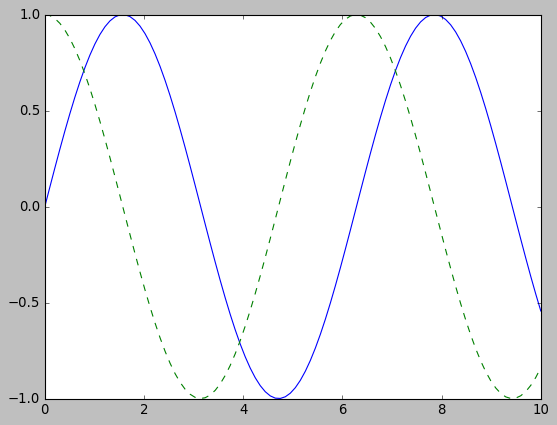

In [5]:
%matplotlib inline
import numpy as np 
x = np.linspace(0, 10, 100) 
fig = plt.figure() 
plt.plot(x, np.sin(x), '-') 
plt.plot(x, np.cos(x), '--');

### 4.1.4　将图形保存为文件
可用将图形保存为各种格式

In [15]:
fig.canvas.get_supported_filetypes() # 获取支持的格式

{'eps': 'Encapsulated Postscript',
 'jpg': 'Joint Photographic Experts Group',
 'jpeg': 'Joint Photographic Experts Group',
 'pdf': 'Portable Document Format',
 'pgf': 'PGF code for LaTeX',
 'png': 'Portable Network Graphics',
 'ps': 'Postscript',
 'raw': 'Raw RGBA bitmap',
 'rgba': 'Raw RGBA bitmap',
 'svg': 'Scalable Vector Graphics',
 'svgz': 'Scalable Vector Graphics',
 'tif': 'Tagged Image File Format',
 'tiff': 'Tagged Image File Format',
 'webp': 'WebP Image Format'}

In [13]:
fig.savefig('my_figure.png')

通过IPython的Image对象显示图像文件

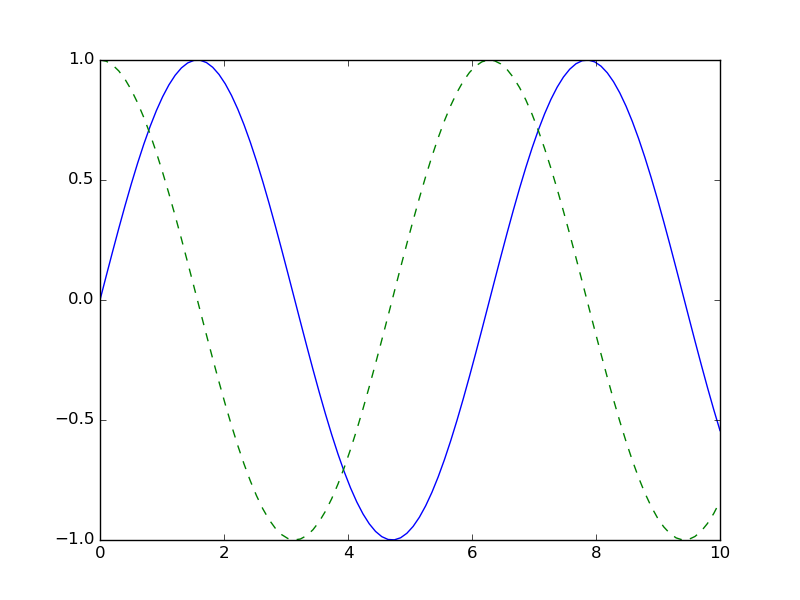

In [12]:
from IPython.display import Image 
Image('my_figure.png')

## 4.2　两种画图接口
- 面向对象接口：更加强大
- MATLAB画风接口

### 4.2.1　MATLAB风格接口
- 位于pyplot（plt）接口中，
- 特性：有状态，任何plt命令都对应当前状态。 比如正在绘制第二个子图，就不太好回到第一个子图。！

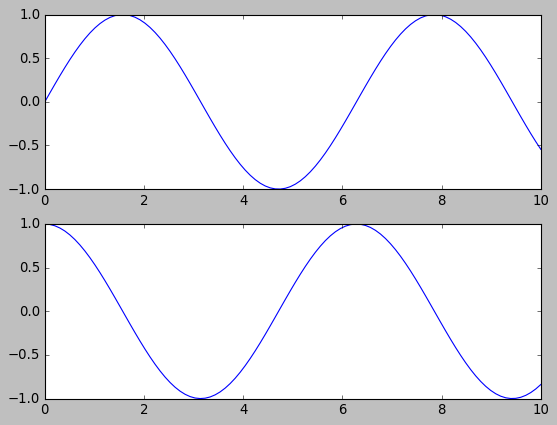

In [17]:
plt.figure() # 生成两个子图
# 创建两个子图中的第一个，设置坐标轴 
plt.subplot(2, 1, 1) # (行、列、子图编号) 
plt.plot(x, np.sin(x)) 

# 创建两个子图中的第二个，设置坐标轴 
plt.subplot(2, 1, 2) 
plt.plot(x, np.cos(x));

### 4.2.2　面向对象接口
- 更加复杂。不会局限在当前状态中。而是通过明确调用figure和axes等方法访问之前的图。
- 即通过ax[i]调用plot， 而不是plt

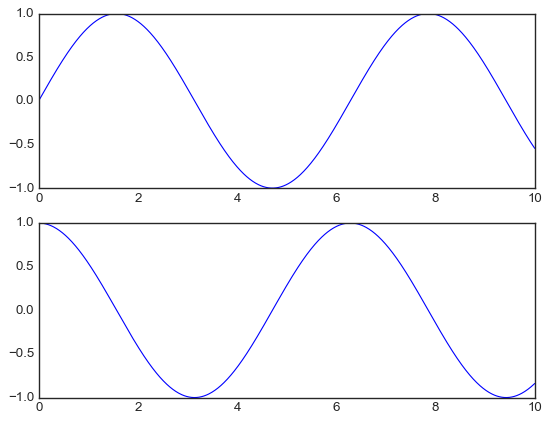

In [54]:
# 先创建图形网格 
# ax是一个包含两个Axes对象（子图）的数组 
fig, ax = plt.subplots(2) 

# 在每个对象上调用plot()方法 
ax[0].plot(x, np.sin(x)) 
ax[1].plot(x, np.cos(x));

### 4.2.3 联系区别
- 大多数plt函数都可以ax直接调用：plot, legend；但是一些设置函数ax需要set调用：plt.xlabel() → ax.set_xlabel()
> 简便的， ax会一起set：
ax.set(xlim=(0, 10), ylim=(-2, 2), 
               xlabel='x', ylabel='sin(x)', 
               title='A Simple Plot');
- plt更加简洁，ax,fig还要创建声明， plt导入即可调用

## 4.3　简易线形图

In [30]:
# 导过一次了
%matplotlib inline  
import matplotlib.pyplot as plt 
plt.style.use('seaborn-v0_8-white')

In [31]:
import numpy as np

> 要画 Matplotlib 图形时，都需要先创建一个图形 fig 和一个坐标轴 ax。
- figure是一个图形容器：坐标轴、文字、标签..。 figure 可以包含多个axes
- axes是一个带有刻度、标签的矩形（坐标轴）

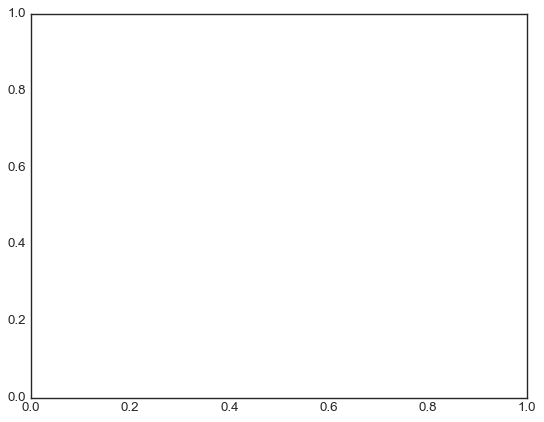

In [32]:
fig = plt.figure()
ax = plt.axes()

> 在ax矩形上绘图， ax.plot

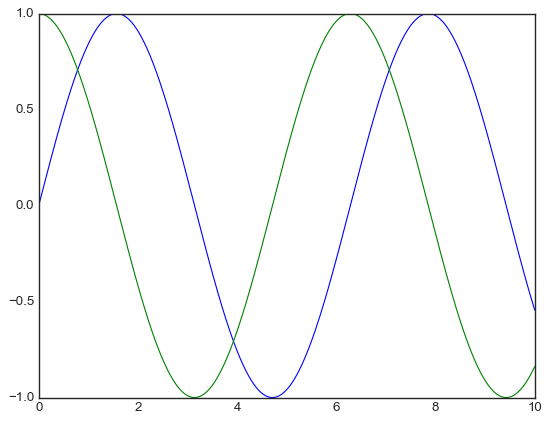

In [35]:
fig = plt.figure() 
ax = plt.axes() 

x = np.linspace(0, 10, 1000) 
ax.plot(x, np.sin(x));
ax.plot(x, np.cos(x))

### 4.3.1　调整图形：线条的颜色与风格
plot对图形的第一次调整是调整它线条的颜色与风格

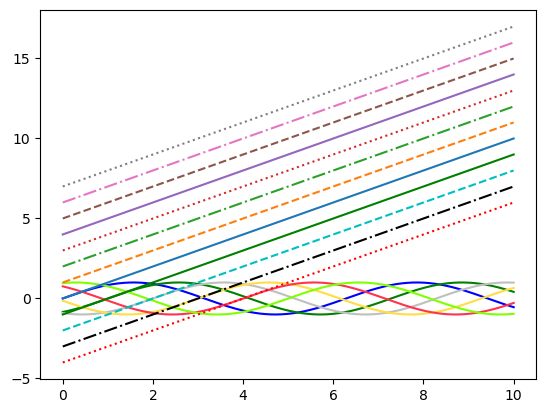

In [23]:
import matplotlib.pyplot as plt
fig = plt.figure() 
ax = plt.axes() 

x = np.linspace(0, 10, 1000) 
# 颜色
ax.plot(x, np.sin(x - 0), color='blue')        # 标准颜色名称 
ax.plot(x, np.sin(x - 1), color='g')           # 缩写颜色代码（rgbcmyk） 
ax.plot(x, np.sin(x - 2), color='0.75')        # 范围在0~1的灰度值 
ax.plot(x, np.sin(x - 3), color='#FFDD44')     # 十六进制（RRGGBB，00~FF） 
ax.plot(x, np.sin(x - 4), color=(1.0,0.2,0.3)) # RGB元组，范围在0~1 
ax.plot(x, np.sin(x - 5), color='chartreuse'); # HTML颜色名称
# 风格
ax.plot(x, x + 0, linestyle='solid') 
ax.plot(x, x + 1, linestyle='dashed') 
ax.plot(x, x + 2, linestyle='dashdot') 
ax.plot(x, x + 3, linestyle='dotted'); 
# 风格简写 
ax.plot(x, x + 4, linestyle='-')  # 实线 
ax.plot(x, x + 5, linestyle='--') # 虚线 
ax.plot(x, x + 6, linestyle='-.') # 点划线 
ax.plot(x, x + 7, linestyle=':');  # 实点线
# 组合简写
plt.plot(x, x - 1, '-g')  # 绿色实线 
plt.plot(x, x - 2, '--c') # 青色虚线
plt.plot(x, x - 3, '-.k') # 黑色点划线 
plt.plot(x, x - 4, ':r');  # 红色实点线

### 4.3.2　调整图形：坐标轴上下限
会自动添加上下限，自定义：ax.set_xlim(), ax.set_ylim()  或者通过axis()一起设置（更加强大）
> ax一般通过set设置

In [ ]:
plt.axis('equal') # 保持X/Y比例一致 1:1

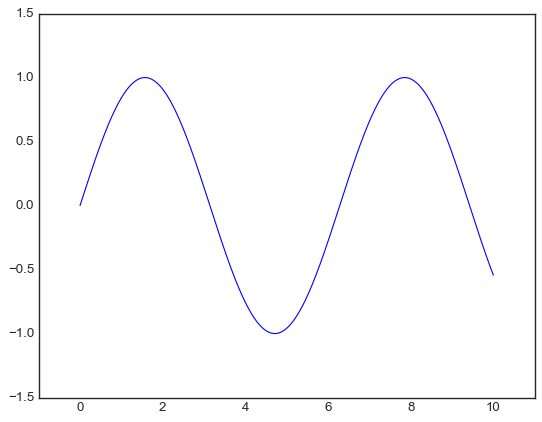

In [44]:
fig = plt.figure() 
ax = plt.axes() 

x = np.linspace(0, 10, 1000) 
ax.plot(x, np.sin(x)) 

ax.set_xlim(-1, 11) 
ax.set_ylim(-1.5, 1.5);

(np.float64(0.0),
 np.float64(10.0),
 np.float64(-0.9999972954811321),
 np.float64(0.9999996994977832))

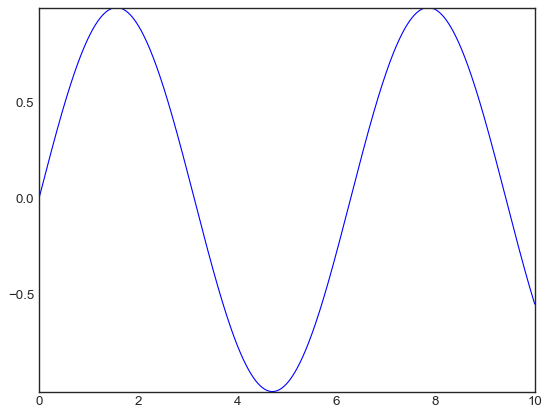

In [49]:
fig = plt.figure() 
ax = plt.axes() 

x = np.linspace(0, 10, 1000) 
ax.plot(x, np.sin(x)) 

ax.axis([-1, 11, -1.5, 1.5]);
ax.axis('tight') # 缩进图

### 4.3.3　设置图形标签
图形标题、坐标轴标题、简易图例。

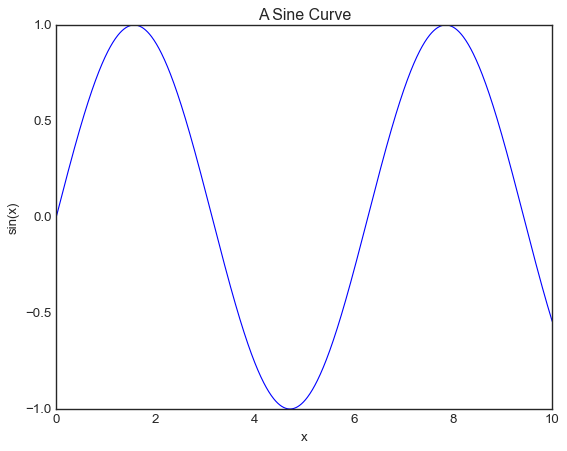

In [52]:
fig = plt.figure() 
ax = plt.axes() 

x = np.linspace(0, 10, 1000) 
ax.plot(x, np.sin(x)) 
ax.set_title("A Sine Curve") 
ax.set_xlabel("x") 
ax.set_ylabel("sin(x)");

图例：legend
- label参数指定， 自动进入图例
- 自定义legend

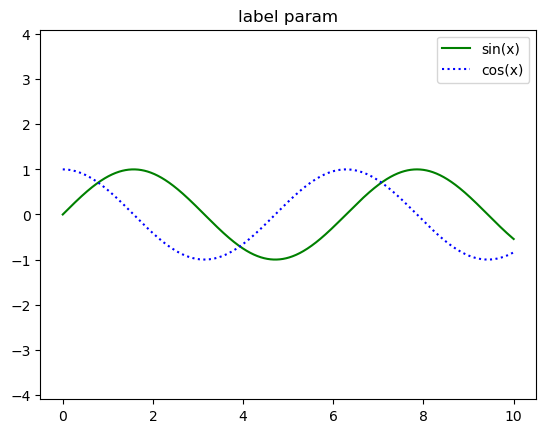

In [4]:
fig = plt.figure() 
ax = plt.axes() 

x = np.linspace(0, 10, 1000) 
ax.plot(x, np.sin(x), '-g', label='sin(x)') 
ax.plot(x, np.cos(x), ':b', label='cos(x)') 
ax.axis('equal') 
ax.set_title('label param')
ax.legend();

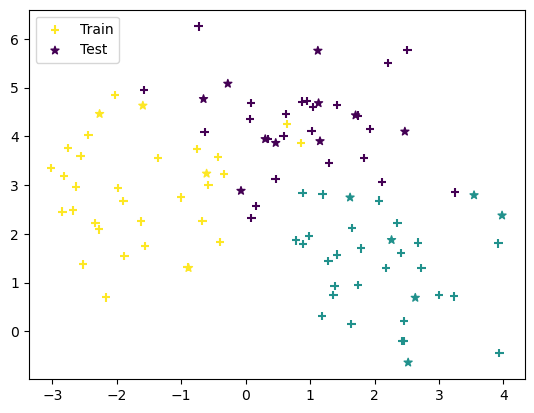

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_blobs
fig, ax = plt.subplots()
X, y = make_blobs(
    n_samples=100,
    n_features=2,
    centers=3,
    random_state=0
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
sca1 = ax.scatter(X_train[:,0], X_train[:, 1], c=y_train, marker='+')
sca2 = ax.scatter(X_test[:,0], X_test[:, 1], c=y_test, marker='*')
ax.legend(
    handles =[sca1, sca2], # 使用哪些图
    labels = ['Train', 'Test'],
    loc='upper left'
)

In [ ]:
z注意：有些对象不支持handle,需要手动画线

## 4.4　简易散点图

In [56]:
%matplotlib inline 
import matplotlib.pyplot as plt 
import numpy as np

### 4.4.1　用.plot画散点图

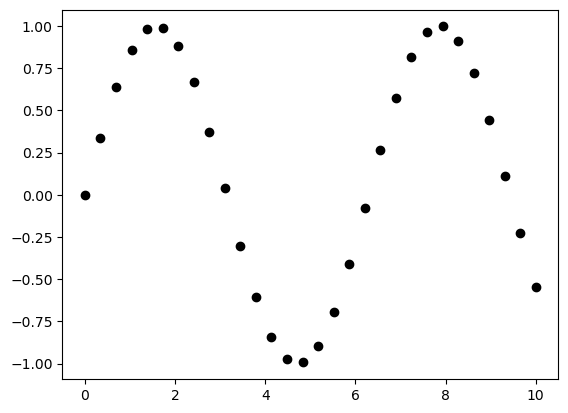

In [3]:
x = np.linspace(0, 10, 30) 
y = np.sin(x) 

plt.plot(x, y, 'o', color='black');

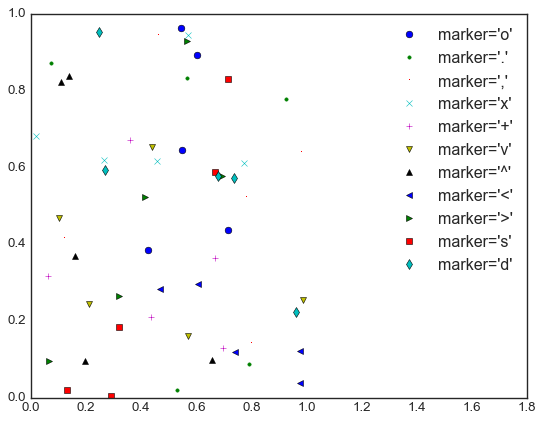

In [60]:
rng = np.random.RandomState(0) 
for marker in ['o', '.', ',', 'x', '+', 'v', '^', '<', '>', 's', 'd']: 
   plt.plot(rng.rand(5), rng.rand(5), marker, # marker属性是 点 字符类型
            label="marker='{0}'".format(marker)) 
   plt.legend(numpoints=1) 
   plt.xlim(0, 1.8);

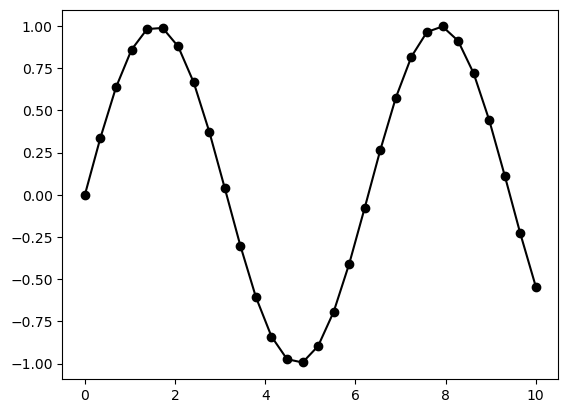

In [5]:
plt.plot(x, y, '-ok');   # 直线（-）、圆圈（o）、黑色（k） 把点连接起来。  简写color, marker, linestyle

### 4.4.2　用plt.scatter画散点图
- 与plot不同的是，scatter可用控制每个点，而plot是整体
- 控制每个点这个特性，可用更直观的看到样本聚集

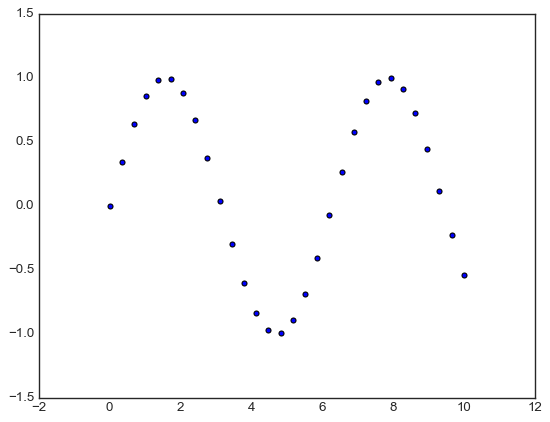

In [63]:
plt.scatter(x, y, marker='o');

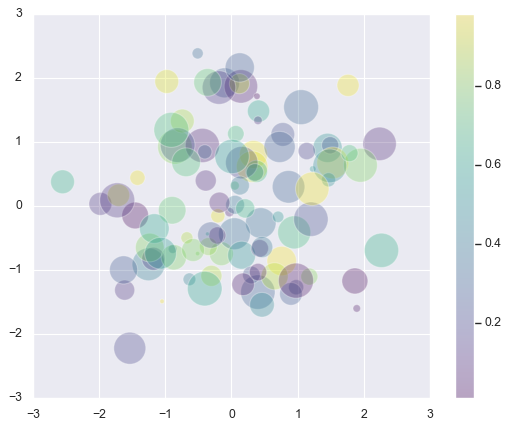

In [181]:
rng = np.random.RandomState(0) 
x = rng.randn(100) 
y = rng.randn(100) 
colors = rng.rand(100) 
sizes = 1000 * rng.rand(100) 

plt.scatter(x, y, c=colors, s=sizes, alpha=0.3, 
           cmap='viridis') 
plt.colorbar();  # 显示颜色条

---
| 参数 | 作用 | 示例 |
|------|------|------|
| `x, y` | **数据点坐标** | `x=[1,2,3], y=[4,5,6]` |
| `s` | **点的大小**（默认 20） | `s=50`（变大） |
| `c` | **颜色**（可以是单色，也可以是数组） | `c='red'` 或 `c=[0,1,2]` |
| `marker` | **点的形状** | `'o'` (圆点), `'^'` (三角), `'s'` (方形) |
| `alpha` | **透明度（0~1）** | `alpha=0.5`（半透明） |
| `edgecolors` | **边缘颜色** | `edgecolors='black'` |
|cmap|颜色映射表，把数字映射到几个颜色|`cmap=plt.colormaps['magma'].resampled(10)`|  
---




## 4.5　可视化 误差

### 4.5.1　基本误差线
errobar

In [65]:
%matplotlib inline 
import matplotlib.pyplot as plt 
import numpy as np 

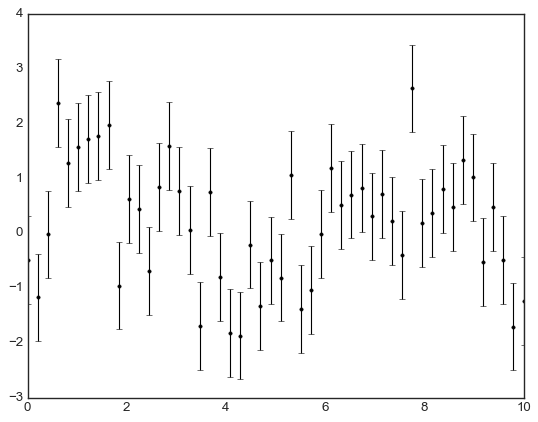

In [66]:
x = np.linspace(0, 10, 50) 
dy = 0.8 
y = np.sin(x) + dy * np.random.randn(50) 

plt.errorbar(x, y, yerr=dy, fmt='.k');

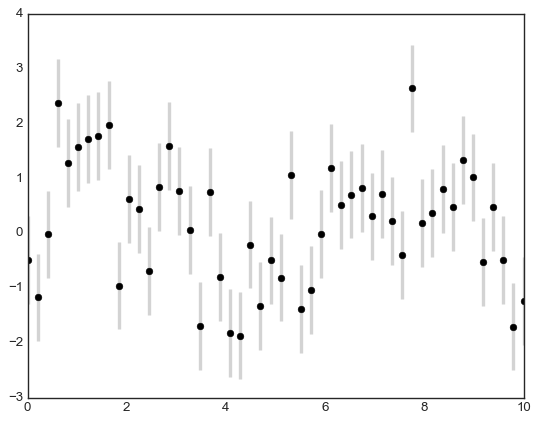

In [67]:
plt.errorbar(x, y, yerr=dy, fmt='o', color='black', ecolor='lightgray', elinewidth=3, capsize=0);

### 4.5.2　连续误差（连续变量）


## 4.6　密度图与等高线图
有时候可以用来表示三维数据

In [2]:
%matplotlib inline 
import matplotlib.pyplot as plt 
import numpy as np

三维函数的可视化

In [3]:
def f(x, y): 
    return np.sin(x) ** 10 + np.cos(10 + y * x) * np.cos(x)
x = np.linspace(0, 5, 50) 
y = np.linspace(0, 5, 40) 

X, Y = np.meshgrid(x, y) # 从一维数组构建二维网格数据
print(X,Y )
Z = f(X, Y)

[[0.         0.10204082 0.20408163 ... 4.79591837 4.89795918 5.        ]
 [0.         0.10204082 0.20408163 ... 4.79591837 4.89795918 5.        ]
 [0.         0.10204082 0.20408163 ... 4.79591837 4.89795918 5.        ]
 ...
 [0.         0.10204082 0.20408163 ... 4.79591837 4.89795918 5.        ]
 [0.         0.10204082 0.20408163 ... 4.79591837 4.89795918 5.        ]
 [0.         0.10204082 0.20408163 ... 4.79591837 4.89795918 5.        ]] [[0.         0.         0.         ... 0.         0.         0.        ]
 [0.12820513 0.12820513 0.12820513 ... 0.12820513 0.12820513 0.12820513]
 [0.25641026 0.25641026 0.25641026 ... 0.25641026 0.25641026 0.25641026]
 ...
 [4.74358974 4.74358974 4.74358974 ... 4.74358974 4.74358974 4.74358974]
 [4.87179487 4.87179487 4.87179487 ... 4.87179487 4.87179487 4.87179487]
 [5.         5.         5.         ... 5.         5.         5.        ]]


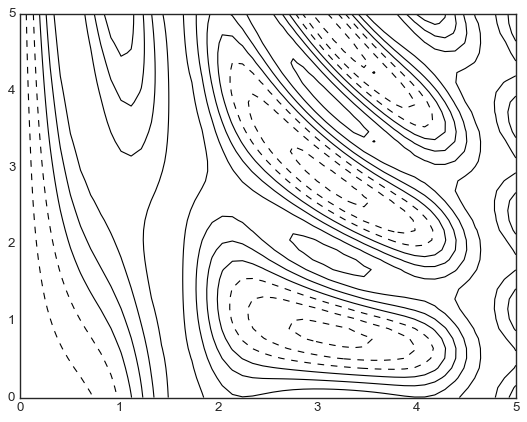

In [75]:
plt.contour(X, Y, Z, colors='black'); # 绘制等高线

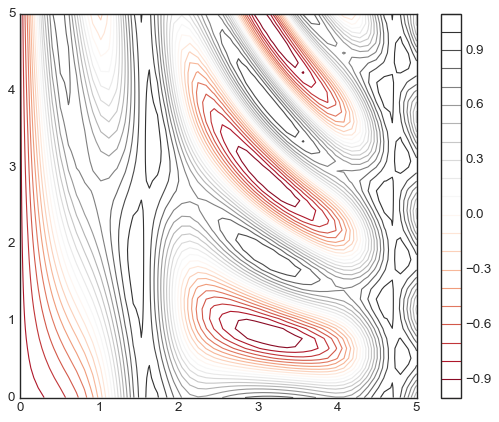

In [81]:
plt.contour(X, Y, Z, 20, cmap='RdGy');
plt.colorbar(); # 绘制颜色对应信息

通过imshow做的更加连续化，而非线条化。

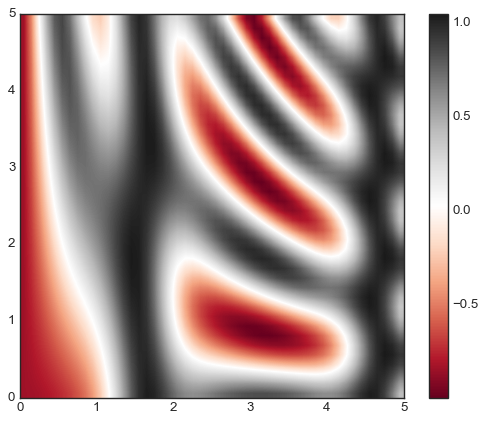

In [84]:
plt.imshow(Z, extent=[0, 5, 0, 5], origin='lower', cmap='RdGy') 
plt.colorbar() 
plt.axis();

还可以一起 将等高线 和 连续图 放在一起。

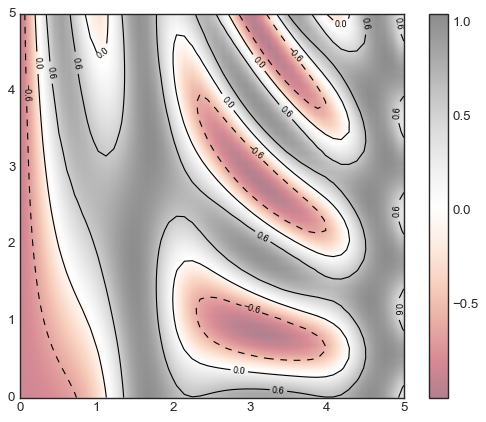

In [83]:

contours = plt.contour(X, Y, Z, 3, colors='black') 
plt.clabel(contours, inline=True, fontsize=8) # 带数据标签的等高线
plt.imshow(Z, extent=[0, 5, 0, 5], origin='lower', cmap='RdGy', alpha=0.5) 
plt.colorbar();

### 绘制二维等高线图
- 等高线必须绘制网格
- 把值要放在网格点上

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

In [7]:
# 二维等高线图，
def plot_contour(x1, x2, y_func):
    fig = plt.figure()
    x1_space = np.linspace(min(x1), max(x1), 1000)
    x2_space = np.linspace(min(x2), max(x2), 1000)
    x1_grid, x2_grid = np.meshgrid(x1_space, x2_space)
    y_grid = y_func(np.column_stack([x1_grid.ravel(), x2_grid.ravel()]))
    y_grid = y_grid.reshape(x1_grid.shape)
    
    plt.contour(x1_grid, x2_grid, y_grid)
    plt.scatter(x1, x2, s=10)
    plt.axis('equal')
    plt.tight_layout()

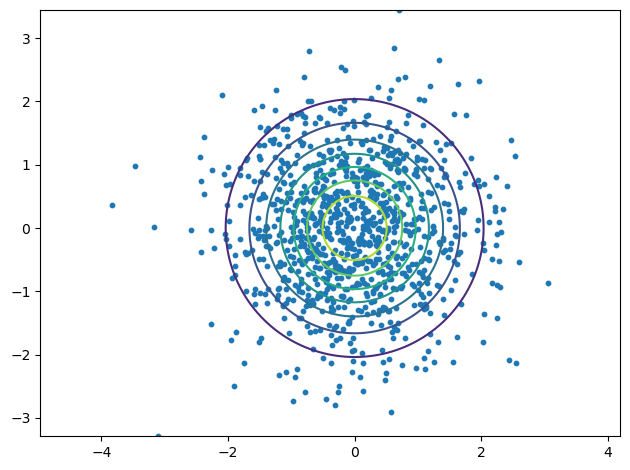

In [8]:
covariance = np.array([
    [1, 0],
    [0, 1]
])
X = np.random.randn(1000, 2)
rv = multivariate_normal(mean=[0, 0], cov= covariance)
plot_contour(X[:, 0], X[:, 1], y_func=rv.pdf)

## 4.7　频次直方图、数据区间划分和分布密度


In [89]:
%matplotlib inline 
import numpy as np 
import matplotlib.pyplot as plt 

data = np.random.randn(1000) 
data.shape

(1000,)

---
hist参数
| 参数         | 描述                                         | 示例                       |
|--------------|----------------------------------------------|----------------------------|
| `bins`       | 柱子的数量或区间边界                        | `bins=30`, `bins='auto'`    |
| `alpha`      | 透明度（0 到 1）                             | `alpha=0.7`                |
| `density`    | 是否显示为概率密度                          | `density=True`             |
| `color`      | 柱子的颜色                                   | `color='skyblue'`          |
| `edgecolor`  | 设置柱子边框颜色                            | `edgecolor='black'`        |
| `linewidth`  | 设置柱子的边框宽度                          | `linewidth=1.5`            |
| `range`      | 直方图的显示范围                             | `range=(0, 10)`            |
| `align`      | 对齐方式                                     | `align='center'`           |
| `histtype`   | 直方图的类型（条形图、线图等）              | `histtype='step'`          |
| `cumulative` | 是否显示为累积直方图                        | `cumulative=True`          |
| `label`      | 为图例指定标签                               | `label='Feature 1'`        |



In [1]:
plt.hist(data);

NameError: name 'plt' is not defined

二维频次直方图与数据区间划分

In [93]:
mean = [0, 0] 
cov = [[1, 1], [1, 2]] 
x, y = np.random.multivariate_normal(mean, cov, 10000).T

1. plt.hist2d：二维频次直方图

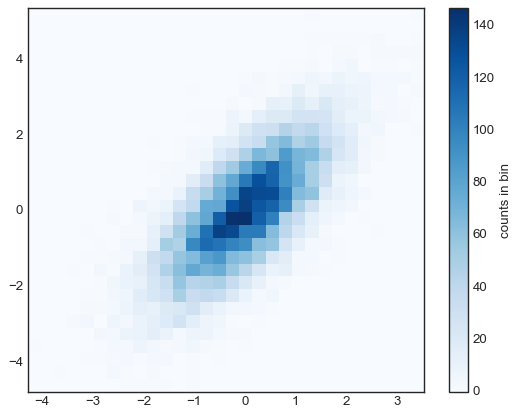

In [94]:
plt.hist2d(x, y, bins=30, cmap='Blues') 
cb = plt.colorbar() 
cb.set_label('counts in bin')

2. plt.hexbin：六边形区间划分

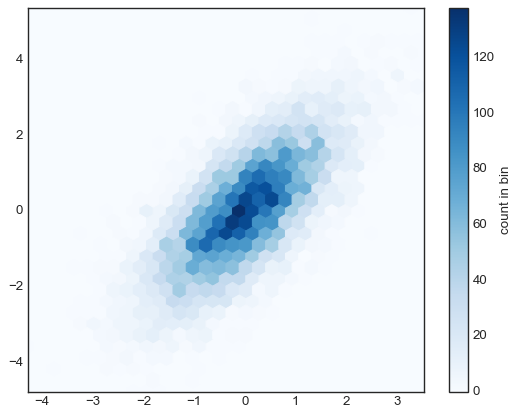

In [95]:
plt.hexbin(x, y, gridsize=30, cmap='Blues') 
cb = plt.colorbar(label='count in bin')

3. 核密度估计：更常见的多维数据分布密度
- 传统的频数分布通过**离散**点统计表示
- KDE通过核函数在每个离散点附近做连续函数，从而连起来产生平滑的概率密度统计

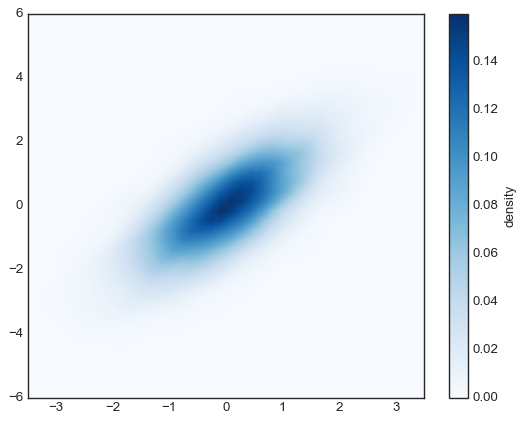

In [96]:
from scipy.stats import gaussian_kde 
 
# 拟合数组维度[Ndim, Nsamples] 
data = np.vstack([x, y]) 
kde = gaussian_kde(data) 

# 用一对规则的网格数据进行拟合 
xgrid = np.linspace(-3.5, 3.5, 40) 
ygrid = np.linspace(-6, 6, 40) 
Xgrid, Ygrid = np.meshgrid(xgrid, ygrid) 
Z = kde.evaluate(np.vstack([Xgrid.ravel(), Ygrid.ravel()])) 

# 画出结果图 
plt.imshow(Z.reshape(Xgrid.shape), 
           origin='lower', aspect='auto', 
           extent=[-3.5, 3.5, -6, 6], 
           cmap='Blues') 
cb = plt.colorbar() 
cb.set_label("density")

## 4.8　配置图例 legend

默认的配置

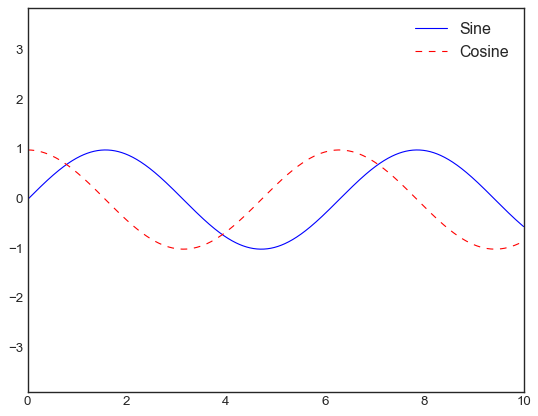

In [97]:
import matplotlib.pyplot as plt 
import numpy as np 
x = np.linspace(0, 10, 1000) 
fig, ax = plt.subplots() 
ax.plot(x, np.sin(x), '-b', label='Sine') 
ax.plot(x, np.cos(x), '--r', label='Cosine') 
ax.axis('equal') 
leg = ax.legend();

### 4.8.1　选择图例显示的元素

### 4.8.2　在图例中显示不同尺寸的点
比如通过圈圈大小显示其人口数


Text(0.5, 1.0, 'California Cities: Area and Population')

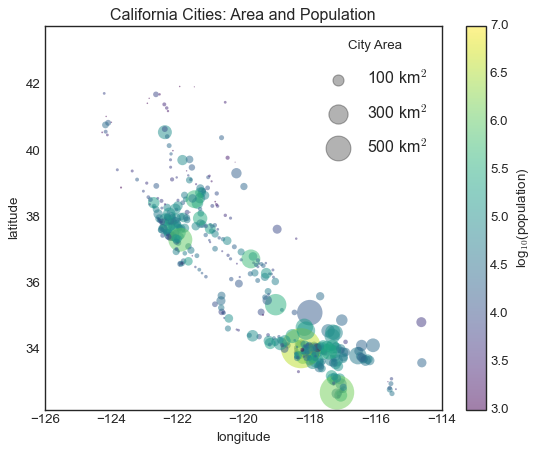

In [104]:
import pandas as pd 
cities = pd.read_csv('california_cities.csv') 

# 提取感兴趣的数据 
lat, lon = cities['latd'], cities['longd'] 
population, area = cities['population_total'], cities['area_total_km2'] 

# 用不同尺寸和颜色的散点图表示数据，但是不带标签 
plt.scatter(lon, lat, label=None, 
           c=np.log10(population), cmap='viridis', 
           s=area, linewidth=0, alpha=0.5) 
plt.axis('equal') 
plt.xlabel('longitude') 
plt.ylabel('latitude') 
plt.colorbar(label='log$_{10}$(population)') 
plt.clim(3, 7) 

# 下面创建一个图例： 
# 画一些带标签和尺寸的空列表 
for area in [100, 300, 500]: 
   plt.scatter([], [], c='k', alpha=0.3, s=area, 
               label=str(area) + ' km$^2$') 
plt.legend(scatterpoints=1, frameon=False, 
          labelspacing=1, title='City Area') 

plt.title('California Cities: Area and Population')

## 4.9　配置颜色条

`plt.imshow(data, cmap='gray', interpolation='none', aspect='auto', extent=[x_min, x_max, y_min, y_max])`  
绘制data形状的像素网格。
- X 轴是 数组的列索引 (0 ~ 19)，Y 轴是 数组的行索引 (0~9)。
- 默认左上角是 (0,0)，行向下增长。
-  extent=[-5, 5, -2, 2] 调整索引长度
-  aspect='auto'自适应比例，

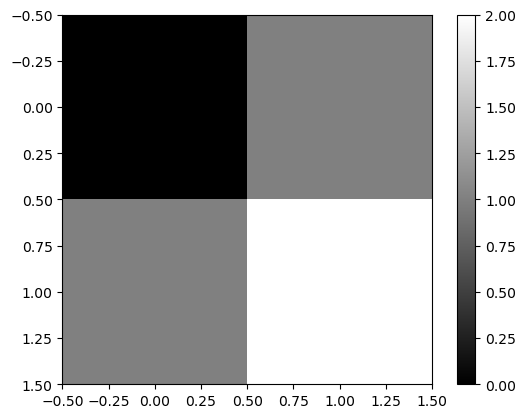

In [4]:
import numpy as np
import matplotlib.pyplot as plt

data = np.array([[0, 1], 
                 [1, 2]])  # 2×2 的数组

plt.imshow(data, cmap="gray", interpolation="nearest")  # 关闭插值，保持像素格
plt.colorbar()  # 添加颜色条
plt.show()


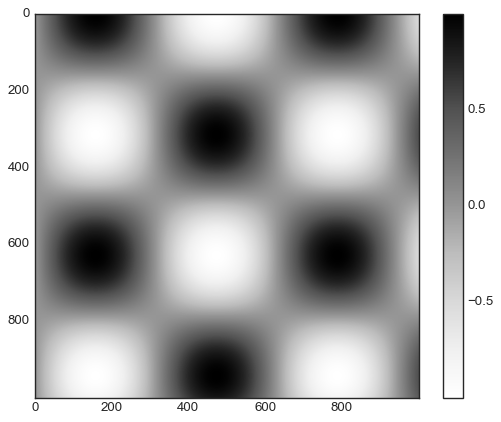

In [106]:
x = np.linspace(0, 10, 1000) 
I = np.sin(x) * np.cos(x[:, np.newaxis]) 

plt.imshow(I) 
plt.colorbar();

### 4.9.1　配置颜色条
通过cmap参数

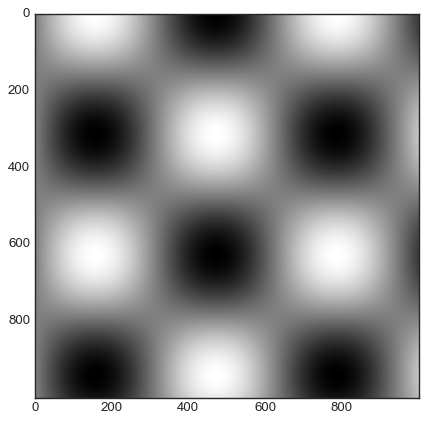

In [107]:
plt.imshow(I, cmap='gray');

### 4.9.2　案例：手写数字

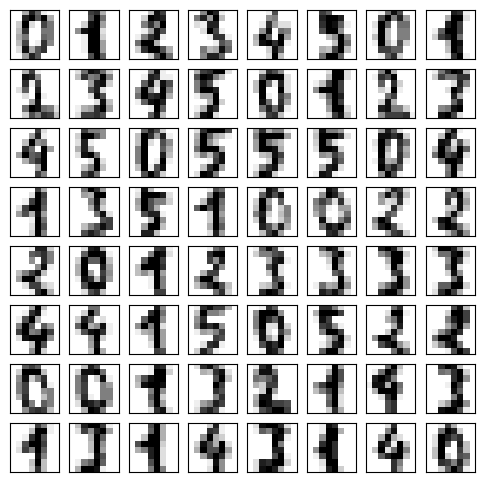

In [13]:
from sklearn.datasets import load_digits 
digits = load_digits(n_class=6) 

fig, ax = plt.subplots(8, 8, figsize=(6, 6)) 
for i, axi in enumerate(ax.flat): 
    axi.imshow(digits.images[i], cmap='binary') 
    axi.set(xticks=[], yticks=[])



### 4.9.3 colorbar
colorbar 是Plt , fig的函数接口  
colorbar 多子图中需要指定ax!!
- matplotlib.cm：处理 colormap，用于从数值获取颜色。
- matplotlib.colors：处理 颜色归一化、转换、定义新颜色。

多子图公用一个colorbar

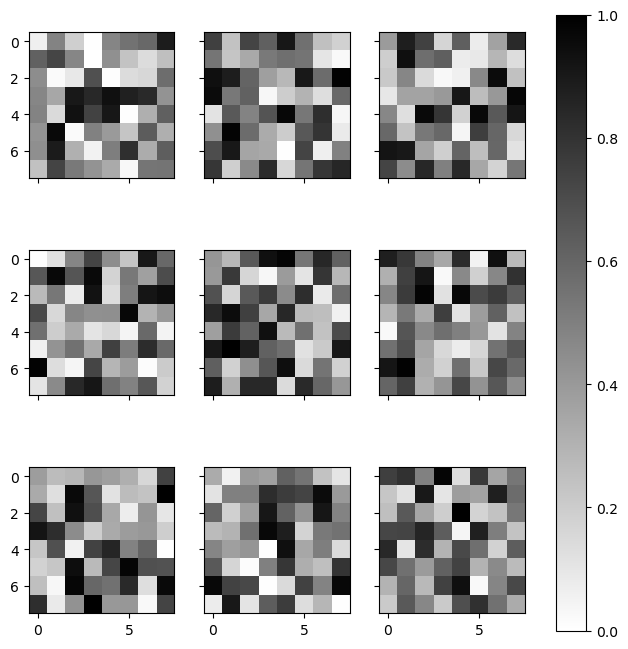

In [34]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# 创建 3x3 子图，X 轴共享列，Y 轴共享行
fig, axes = plt.subplots(3, 3, sharex='col', sharey='row', figsize=(8, 8))

# 颜色映射
vmin, vmax = 0, 1  # 设定 colorbar 的范围
cmap = cm.binary
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

# 创建 ScalarMappable（用于 colorbar）
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # 避免 colorbar() 警告

# 遍历子图
for row in axes:
    for ax in row:
        img = np.random.rand(8, 8)  # 生成 8x8 数据
        ax.imshow(img, cmap=cmap, norm=norm)  # ✅ 直接用 sm 的 cmap 和 norm

# 统一色条
fig.colorbar(sm, ax=axes.ravel(), orientation="vertical")


## 4.10　多子图
- 画中画（inset）、网格图（grid of plots），或者是其他更复杂的布局形式
- 一个figure，而ax有多个

In [11]:
%matplotlib inline 
import matplotlib.pyplot as plt 
import numpy as np

### 4.10.1　plt.axes：手动创建子图

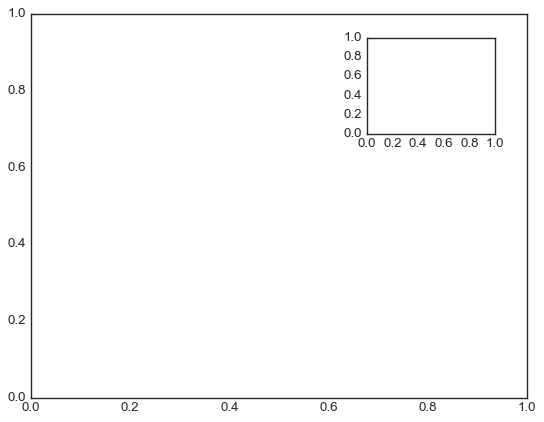

In [115]:
ax1 = plt.axes()  # 默认坐标轴 
ax2 = plt.axes([0.65, 0.65, 0.2, 0.2]) # 百分比高度，

### 4.10.2　plt.subplot：简易网格子图：若干彼此对齐的行列子图

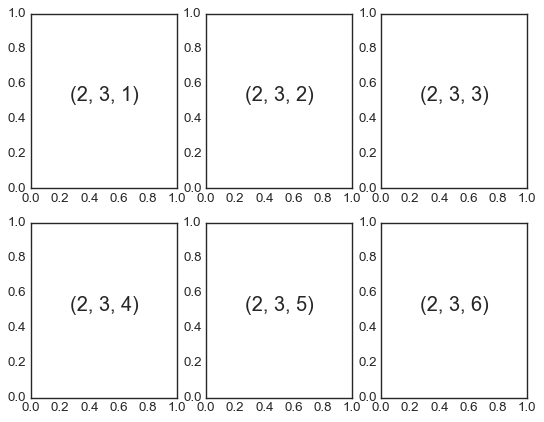

In [116]:
for i in range(1, 7): 
   plt.subplot(2, 3, i) 
   plt.text(0.5, 0.5, str((2, 3, i)), 
            fontsize=18, ha='center')

### 4.10.3　plt.subplots：用一行代码创建网格
- subplot不能隐藏坐标轴啥的， 太简单了
- s表示一次创建多个

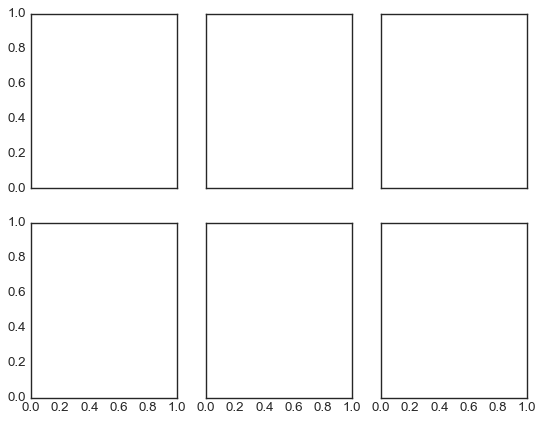

In [117]:
fig, axes = plt.subplots(2, 3, sharex='col', sharey='row')

### 4.10.4　plt.GridSpec：实现更复杂的排列方式
不规格的网格图

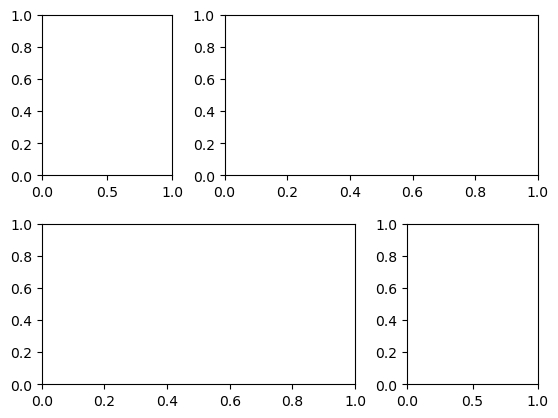

In [4]:
grid = plt.GridSpec(2, 3, wspace=0.4, hspace=0.3)
plt.subplot(grid[0, 0]) 
plt.subplot(grid[0, 1:]) 
plt.subplot(grid[1, :2]) 
plt.subplot(grid[1, 2]);

### 4.10.5  add_subplot 直接添加

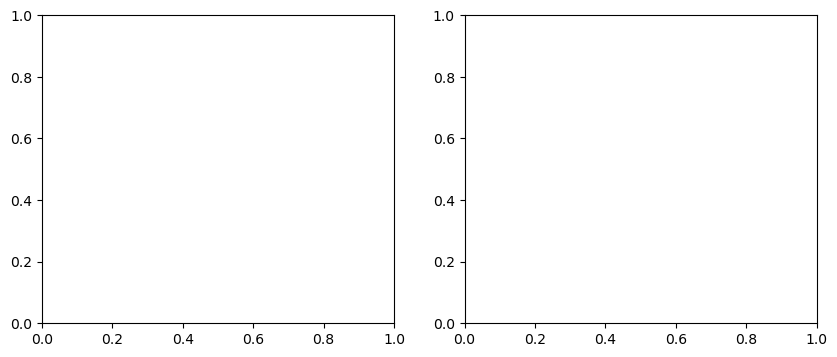

In [8]:
fig = plt.figure(figsize=(10 ,4))
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)

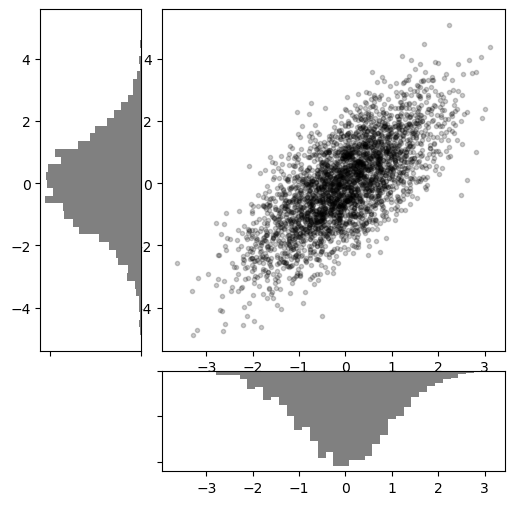

In [12]:
# 创建一些正态分布数据 
mean = [0, 0] 
cov = [[1, 1], [1, 2]] 
x, y = np.random.multivariate_normal(mean, cov, 3000).T 

# 设置坐标轴和网格配置方式 
fig = plt.figure(figsize=(6, 6)) 
grid = plt.GridSpec(4, 4, hspace=0.2, wspace=0.2) 
main_ax = fig.add_subplot(grid[:-1, 1:]) 
y_hist = fig.add_subplot(grid[:-1, 0], xticklabels=[], sharey=main_ax) 
x_hist = fig.add_subplot(grid[-1, 1:], yticklabels=[], sharex=main_ax) 

# 主坐标轴画散点图 
main_ax.plot(x, y, 'ok', markersize=3, alpha=0.2) 

# 次坐标轴画频次直方图 
x_hist.hist(x, 40, histtype='stepfilled', 
            orientation='vertical', color='gray') 
x_hist.invert_yaxis() 

y_hist.hist(y, 40, histtype='stepfilled', 
            orientation='horizontal', color='gray') 
y_hist.invert_xaxis()

## 4.11　文字与注释

In [1]:
import matplotlib.pyplot as plt 
import matplotlib as mpl 
import numpy as np 
import pandas as pd

In [3]:
births = pd.read_csv('births.csv')
births.head()

,year,month,day,gender,births
0,1969,1,1.0,F,4046
1,1969,1,1.0,M,4440
2,1969,1,2.0,F,4454
3,1969,1,2.0,M,4548
4,1969,1,3.0,F,4548


In [5]:
quartiles = np.percentile(births['births'], [25, 50, 75])
quartiles

array([4358. , 4814. , 5289.5])

In [7]:
mu, sig = quartiles[1], 0.74 * (quartiles[2] - quartiles[0])
mu,sig

(np.float64(4814.0), np.float64(689.31))

In [12]:
births = births.query('(births > @mu - 5 * @sig) & (births < @mu + 5 * @sig)')
births.head()

,year,month,day,gender,births
0,1969,1,1,F,4046
1,1969,1,1,M,4440
2,1969,1,2,F,4454
3,1969,1,2,M,4548
4,1969,1,3,F,4548


In [13]:
births['day'] = births['day'].astype(int)
births.head()

,year,month,day,gender,births
0,1969,1,1,F,4046
1,1969,1,1,M,4440
2,1969,1,2,F,4454
3,1969,1,2,M,4548
4,1969,1,3,F,4548


In [20]:
births.index = pd.to_datetime(10000 * births.year + 100 * births.month + births.day, format= '%Y%m%d' )
births.index

DatetimeIndex(['1969-01-01', '1969-01-01', '1969-01-02', '1969-01-02',
               '1969-01-03', '1969-01-03', '1969-01-04', '1969-01-04',
               '1969-01-05', '1969-01-05',
               ...
               '1988-12-27', '1988-12-27', '1988-12-28', '1988-12-28',
               '1988-12-29', '1988-12-29', '1988-12-30', '1988-12-30',
               '1988-12-31', '1988-12-31'],
              dtype='datetime64[ns]', length=14610, freq=None)

In [21]:
births_by_date = births.pivot_table('births', 
                                    [births.index.month, births.index.day]) 
births_by_date

births
1  1   4009.225
   2   4247.400
   3   4500.900
   4   4571.350
   5   4603.625
...         ...
12 27  4850.150
   28  5044.200
   29  5120.150
   30  5172.350
   31  4859.200

[366 rows x 1 columns]

In [23]:
births_by_date.index = [pd.Timestamp(2012, month, day)
                        for (month, day) in births_by_date.index] 

In [30]:
births_by_date

,births
2012-01-01,4009.225
2012-01-02,4247.400
2012-01-03,4500.900
2012-01-04,4571.350
2012-01-05,4603.625
...,...
2012-12-27,4850.150
2012-12-28,5044.200
2012-12-29,5120.150
2012-12-30,5172.350


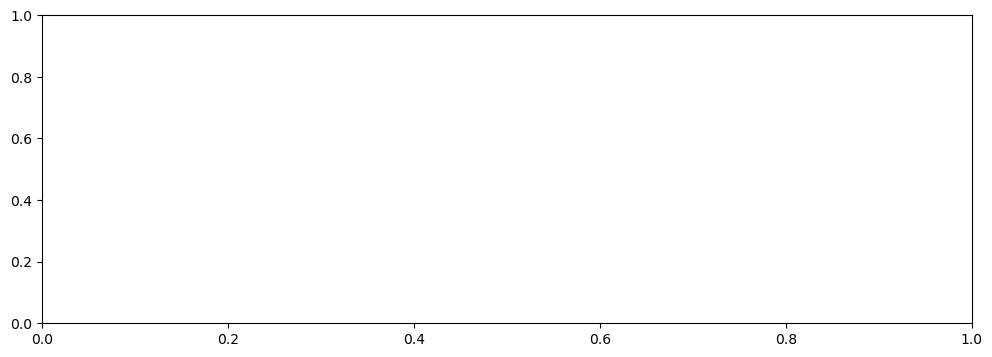

In [25]:
fig, ax = plt.subplots(figsize = (12,4))

In [32]:
ax.plot(births_by_date)
fig

C:\Users\63517\AppData\Local\Temp\ipykernel_13876\4018282542.py:1: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(births_by_date)


ConversionError: Failed to convert value(s) to axis units: '2012-1-1'

<Figure size 1200x400 with 1 Axes>

添加文字标题

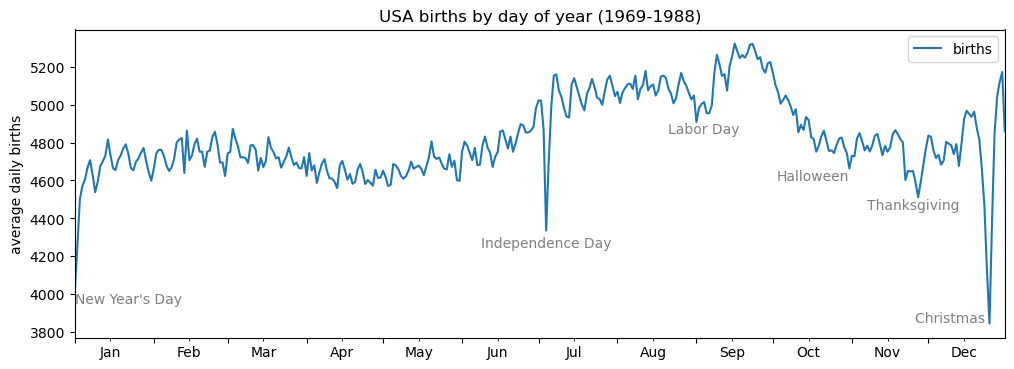

In [31]:
fig, ax = plt.subplots(figsize=(12, 4)) 
births_by_date.plot(ax=ax) 

# 在图上增加文字标签 
style = dict(size=10, color='gray') 

ax.text('2012-1-1', 3950, "New Year's Day", **style) 
ax.text('2012-7-4', 4250, "Independence Day", ha='center', **style) 
ax.text('2012-9-4', 4850, "Labor Day", ha='center', **style) 
ax.text('2012-10-31', 4600, "Halloween", ha='right', **style) 
ax.text('2012-11-25', 4450, "Thanksgiving", ha='center', **style) 
ax.text('2012-12-25', 3850, "Christmas ", ha='right', **style) 

# 设置坐标轴标题 
ax.set(title='USA births by day of year (1969-1988)', 
      ylabel='average daily births') 

# 设置x轴刻度值，让月份居中显示 
ax.xaxis.set_major_locator(mpl.dates.MonthLocator()) 
ax.xaxis.set_minor_locator(mpl.dates.MonthLocator(bymonthday=15)) 
ax.xaxis.set_major_formatter(plt.NullFormatter()) 
ax.xaxis.set_minor_formatter(mpl.dates.DateFormatter('%h'));

### 4.11.2　坐标变换与文字位置

### 4.11.3　箭头与注释
plt.annonate 既可以画箭头 又能注释

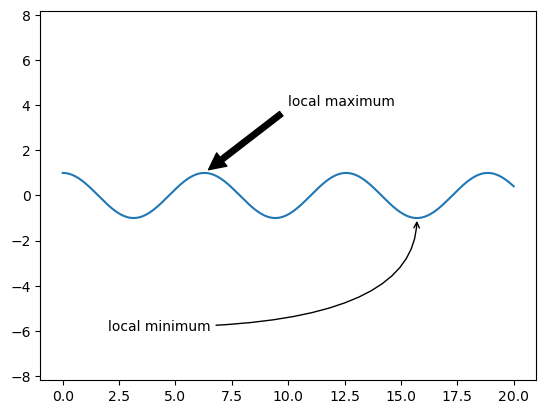

In [34]:
fig, ax = plt.subplots() 
x = np.linspace(0, 20, 1000) 
ax.plot(x, np.cos(x)) 
ax.axis('equal') 
ax.annotate('local maximum', xy=(6.28, 1), xytext=(10, 4), 
       arrowprops=dict(facecolor='black', shrink=0.05)) 
ax.annotate('local minimum', xy=(5 * np.pi, -1), xytext=(2, -6), 
       arrowprops=dict(arrowstyle="->", 
                       connectionstyle="angle3,angleA=0,angleB=-90"));

## 4.12　自定义坐标轴刻度

### 4.12.1　主要刻度与次要刻度

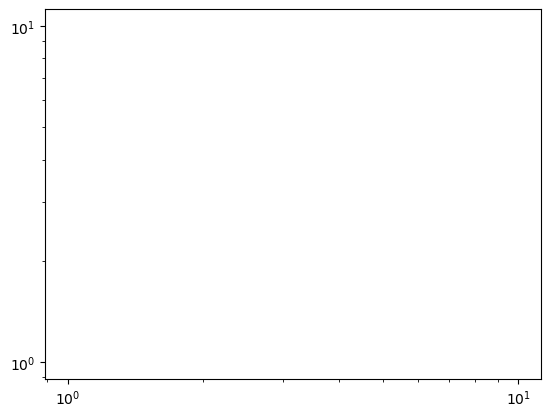

In [35]:
import matplotlib.pyplot as plt 
import numpy as np 
ax = plt.axes(xscale='log', yscale='log')

**！每个坐标轴的 formatter（刻度） 与 locator 对象（标签）** 设置坐标轴

### 4.12.2　隐藏刻度与标签

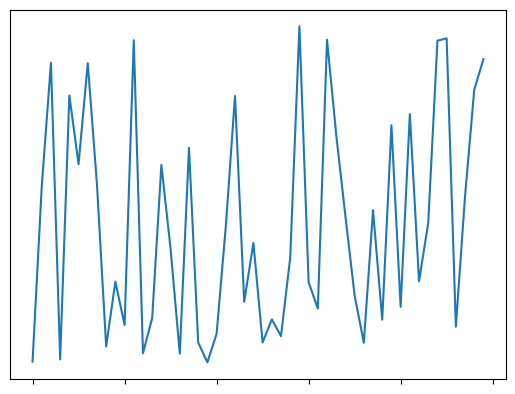

In [38]:
ax = plt.axes() 
ax.plot(np.random.rand(50)) 

ax.yaxis.set_major_locator(plt.NullLocator()) # 隐藏刻度
ax.xaxis.set_major_formatter(plt.NullFormatter()) # 隐藏标签

比如人脸数据图像，不需要刻度

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to C:\Users\63517\scikit_learn_data


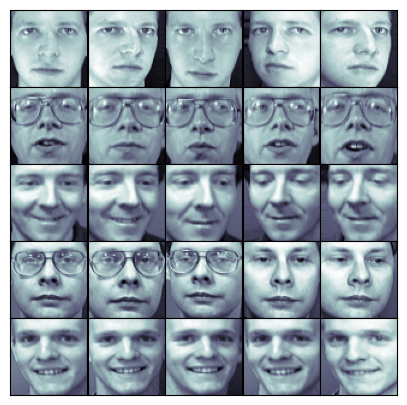

In [40]:
fig, ax = plt.subplots(5, 5, figsize=(5, 5))  # 行，列，fig宽高
fig.subplots_adjust(hspace=0, wspace=0) # 调整subplots

# 从scikit-learn获取一些人脸照片数据 
from sklearn.datasets import fetch_olivetti_faces 
faces = fetch_olivetti_faces().images 

for i in range(5): 
   for j in range(5): 
       ax[i, j].xaxis.set_major_locator(plt.NullLocator()) 
       ax[i, j].yaxis.set_major_locator(plt.NullLocator()) 
       ax[i, j].imshow(faces[10 * i + j], cmap="bone")

### 4.12.3　增减刻度数量

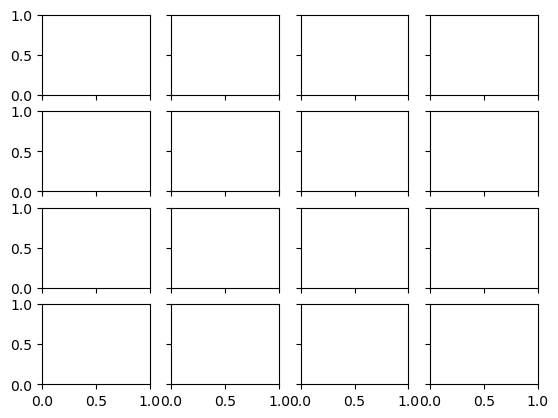

In [41]:
fig, ax = plt.subplots(4, 4, sharex=True, sharey=True)

### 4.12.4　花哨的刻度格式

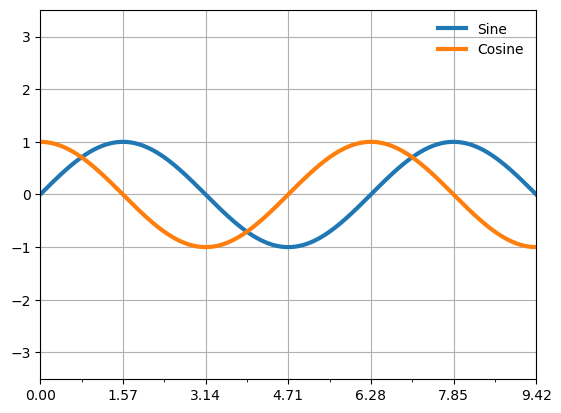

In [43]:
# 画正弦曲线和余弦曲线 
fig, ax = plt.subplots() 
x = np.linspace(0, 3 * np.pi, 1000) 
ax.plot(x, np.sin(x), lw=3, label='Sine') 
ax.plot(x, np.cos(x), lw=3, label='Cosine') 

# 设置网格、图例和坐标轴上下限 
ax.grid(True) 
ax.legend(frameon=False) 
ax.axis('equal') 
ax.set_xlim(0, 3 * np.pi);
ax.xaxis.set_major_locator(plt.MultipleLocator(np.pi / 2)) 
ax.xaxis.set_minor_locator(plt.MultipleLocator(np.pi / 4)) 


## 4.13　Matplotlib自定义：配置文件与样式表

## 4.14　用Matplotlib画三维图

In [2]:
from mpl_toolkits import mplot3d

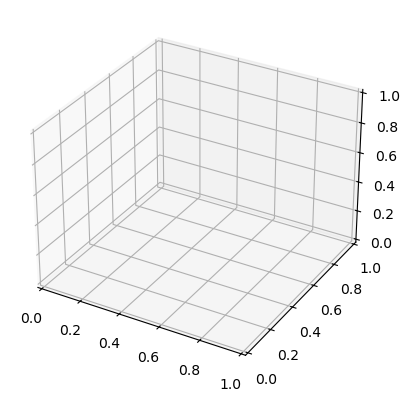

In [3]:
import numpy as np 
import matplotlib.pyplot as plt 
fig = plt.figure() 
ax = plt.axes(projection='3d') # 3D坐标轴

%matplotlib notebook 可以交互浏览， 而非inline静止

### 4.14.1　三维数据点与线

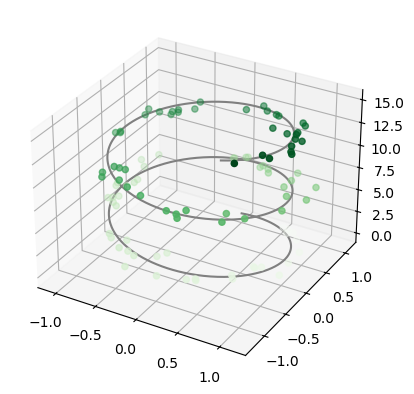

In [55]:
%matplotlib inline
ax = plt.axes(projection='3d') 
 
# 三维线的数据 
zline = np.linspace(0, 15, 1000) 
xline = np.sin(zline) 
yline = np.cos(zline) 
ax.plot3D(xline, yline, zline, 'gray') 

# 三维散点的数据 
zdata = 15 * np.random.random(100) 
xdata = np.sin(zdata) + 0.1 * np.random.randn(100) 
ydata = np.cos(zdata) + 0.1 * np.random.randn(100) 
ax.scatter3D(xdata, ydata, zdata, c=zdata, cmap='Greens');


### 4.14.2　三维等高线图

(30, 30) (30, 30) (30, 30)
(30, 30)


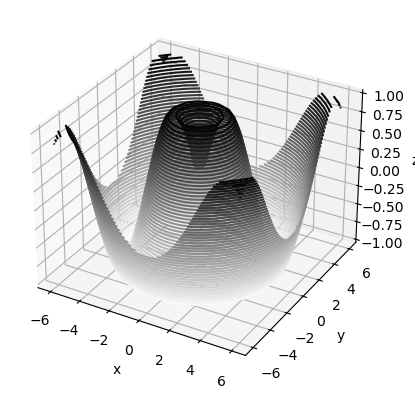

In [5]:
import numpy as np
def f(x, y): 
   return np.sin(np.sqrt(x ** 2 + y ** 2)) 

x = np.linspace(-6, 6, 30) 
y = np.linspace(-6, 6, 30) 

X, Y = np.meshgrid(x, y) 
Z = f(X, Y) 
print(X.shape, Y.shape, Z.shape)

fig = plt.figure() 
ax = plt.axes(projection='3d') 
ax.contour3D(X, Y, Z, 50, cmap='binary') 
ax.set_xlabel('x') 
ax.set_ylabel('y') 
ax.set_zlabel('z');


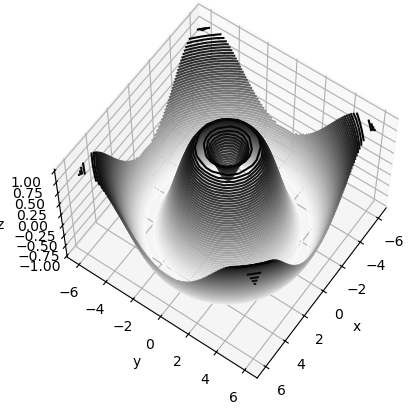

In [58]:
ax.view_init(60, 35)  # 扭转角度
fig

### 4.14.4　曲面三角剖分
有时候数据没那么多，通过三点构建曲面三角，构建整体图像

In [60]:
theta = 2 * np.pi * np.random.random(1000) 
r = 6 * np.random.random(1000) 
x = np.ravel(r * np.sin(theta)) 
y = np.ravel(r * np.cos(theta)) 
z = f(x, y)

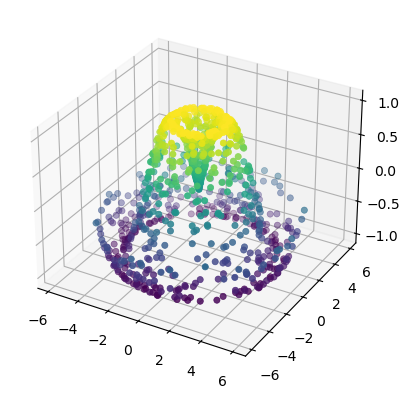

In [62]:
ax = plt.axes(projection='3d') 
ax.scatter(x, y, z, c=z, cmap='viridis', linewidth=0.5);

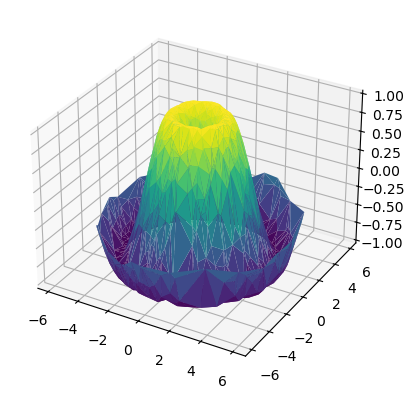

In [63]:
ax = plt.axes(projection='3d') 
ax.plot_trisurf(x, y, z, cmap='viridis', edgecolor='none'); # 把散点连起来三角

**案例：莫比乌斯带**

莫比乌斯带的参数方程为：

$$
x = (1 + v \cos \frac{u}{2}) \cos u
$$

$$
y = (1 + v \cos \frac{u}{2}) \sin u
$$

$$
z = v \sin \frac{u}{2}
$$

其中：
- $( u \in [0, 2\pi])$ 控制绕圈的角度。
- $( v \in [-w, w] ) $控制带的宽度。



In [75]:
theta = np.linspace(0, 2 * np.pi, 30) 
w = np.linspace(-0.25, 0.25, 8) 
w, theta = np.meshgrid(w, theta)
phi = 0.5 * theta
# x - y平面内的半径 
r = 1 + w * np.cos(phi) 

x = np.ravel(r * np.cos(theta)) # np.ravel多维数组展成一维数组
y = np.ravel(r * np.sin(theta)) 
z = np.ravel(w * np.sin(phi))

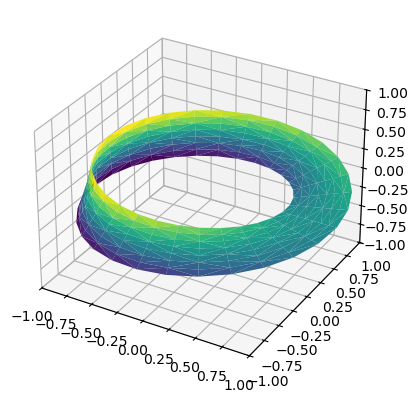

In [77]:
from matplotlib.tri import Triangulation 
tri = Triangulation(np.ravel(w), np.ravel(theta)) 

ax = plt.axes(projection='3d') 
ax.plot_trisurf(x, y, z, triangles=tri.triangles, 
                cmap='viridis', linewidths=0.2); 

ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_zlim(-1, 1);

## 4.15　用Basemap可视化地理数据 （过时）现在：cartopy

## 4.16　用Seaborn做数据可视化
seaborn 接口返回值：
- ax: 表示单图，
- Grid: 表示多图。
- Figure：特例。聚类图不常见。
https://seaborn.pydata.org/tutorial.html

Axes(0.125,0.11;0.775x0.77)


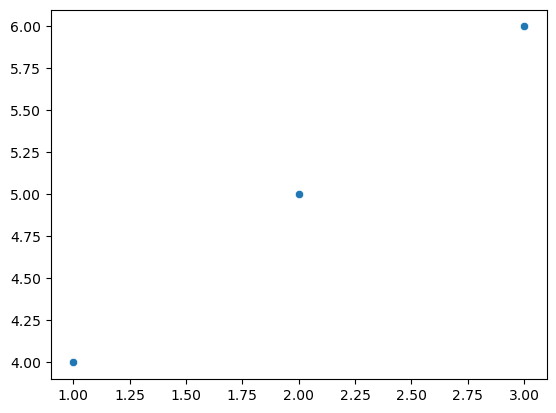

In [1]:
import seaborn as sns

ax = sns.scatterplot(x=[1, 2, 3], y=[4, 5, 6])  # 返回 Axes
print(ax)  # <AxesSubplot: ...>  


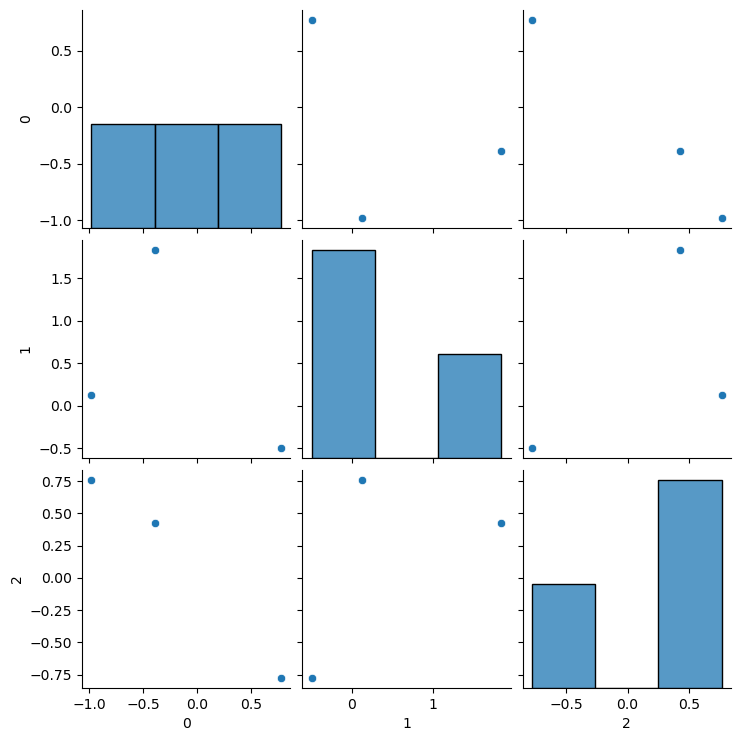

In [10]:
import numpy as np
import pandas as pd
zz = np.random.randn(3,3)
df = pd.DataFrame(zz)
sns.pairplot(df)

### 4.16.1　Seaborn与Matplotlib
- 如果是ax-level接口,返回ax对象; 如histplot、scatterplt
- figure-level接口，返回网格对象，通过.figure, .axes获取; 如pairplot

In [3]:
import matplotlib.pyplot as plt 
plt.style.use('classic') 
%matplotlib inline 
import numpy as np 
import pandas as pd

In [17]:
# 创建一些数据 
rng = np.random.RandomState(0) 
x = np.linspace(0, 10, 500) 
y = np.cumsum(rng.randn(500, 6), 0) # 累积求和。  生成500*6矩阵，然后列聚合， 500*1

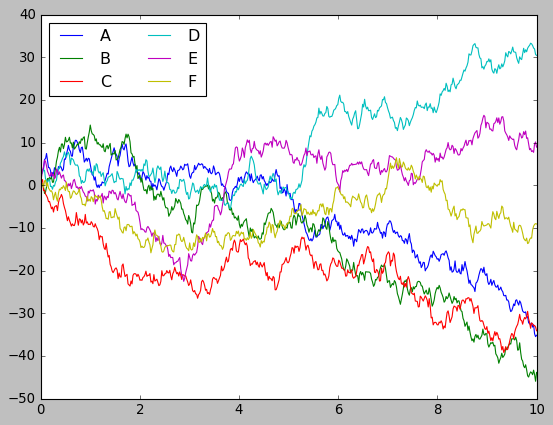

In [18]:
# 用Matplotlib默认样式画图 
plt.plot(x, y) 
plt.legend('ABCDEF', ncol=2, loc='upper left');

In [19]:
import seaborn as sns 
sns.set()

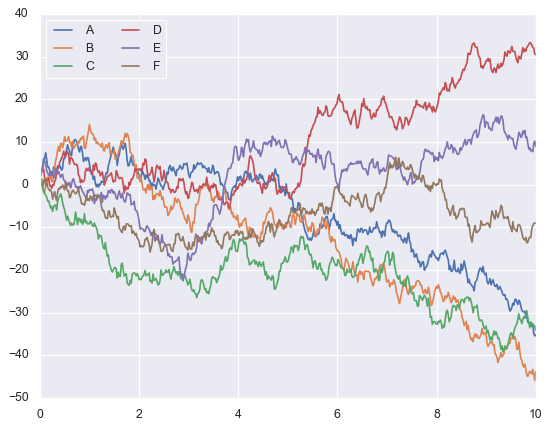

In [20]:
# 同样的代码，seaborn绘图
plt.plot(x, y) 
plt.legend('ABCDEF', ncol=2, loc='upper left');

**更好看了seaborn**

### 4.16.2　Seaborn图形介绍

默认很多时候出发legend

#### 1. 频次直方图、KDE和密度图：数据分布


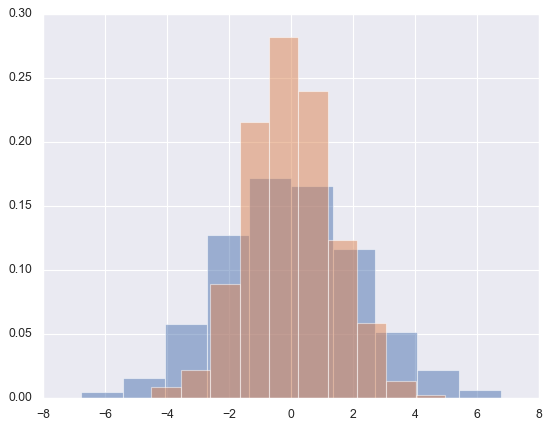

In [21]:
data = np.random.multivariate_normal([0, 0], [[5, 2], [2, 2]], size=2000) # 生成2000个二维正太分布点
data = pd.DataFrame(data, columns=['x', 'y']) 

for col in 'xy':  # 遍历xy列，  绘制x和y两个方向的hist
   plt.hist(data[col], density=True, alpha=0.5) # density=True 直方图面积和1

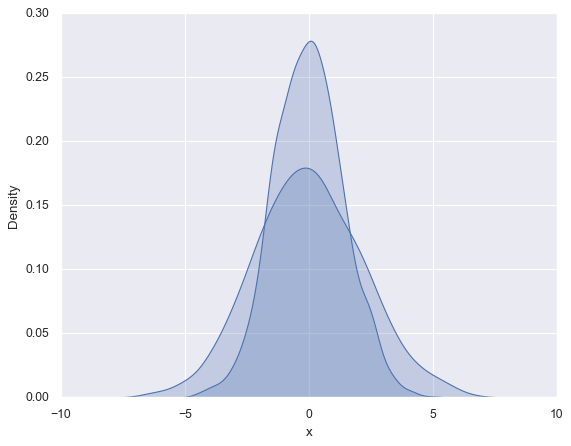

In [22]:
for col in 'xy': 
    sns.kdeplot(data[col], fill=True) # KDE平滑图

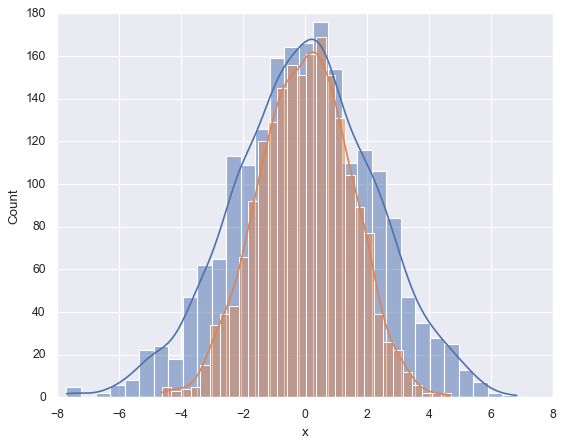

In [8]:
sns.histplot (data['x'], kde=True) # 平滑图和直方图
sns.histplot (data['y'], kde=True);

二维图

<Axes: xlabel='x', ylabel='y'>

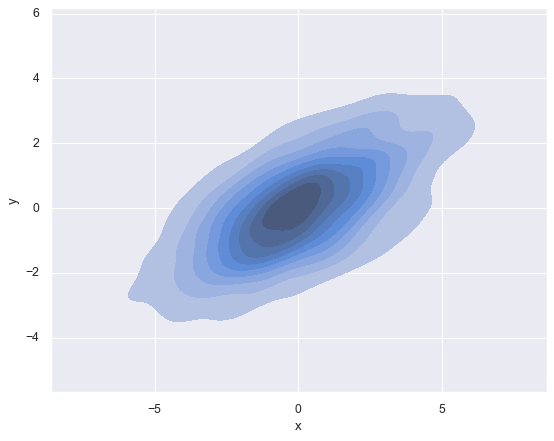

In [23]:
sns.kdeplot(data=data, x='x', y='y', fill=True)

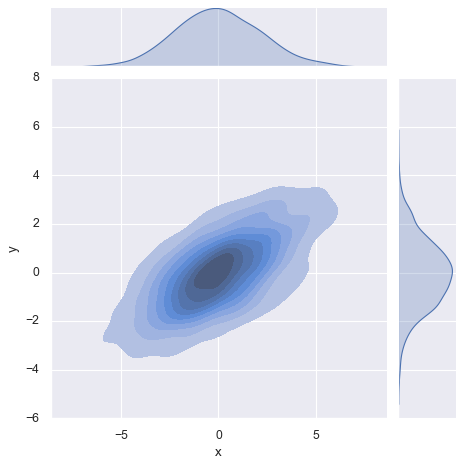

In [24]:
# 使用 jointplot 绘制二维数据的关系，  会带有变量的分布
sns.jointplot(data=data, x='x', y='y', kind='kde', fill=True)

#### 2. 矩阵图： 多组2变量关系
对多维数据可视化，常常需要所有两个变量的关系，探索不同维度之间的相关性。

In [25]:
iris = sns.load_dataset("iris") 
iris.head() 

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


sns.pairplot  
- kind: 图类型。 scatter默认。 'kde'平滑曲线
- diag_kind='kde':对角线上的图用KDE代替直方图hist
- hue : 按类别着色， 值为一个列名
- palette: 调色方案. 如'deep'
- height: 每个子图大小
- aspect: 长宽比

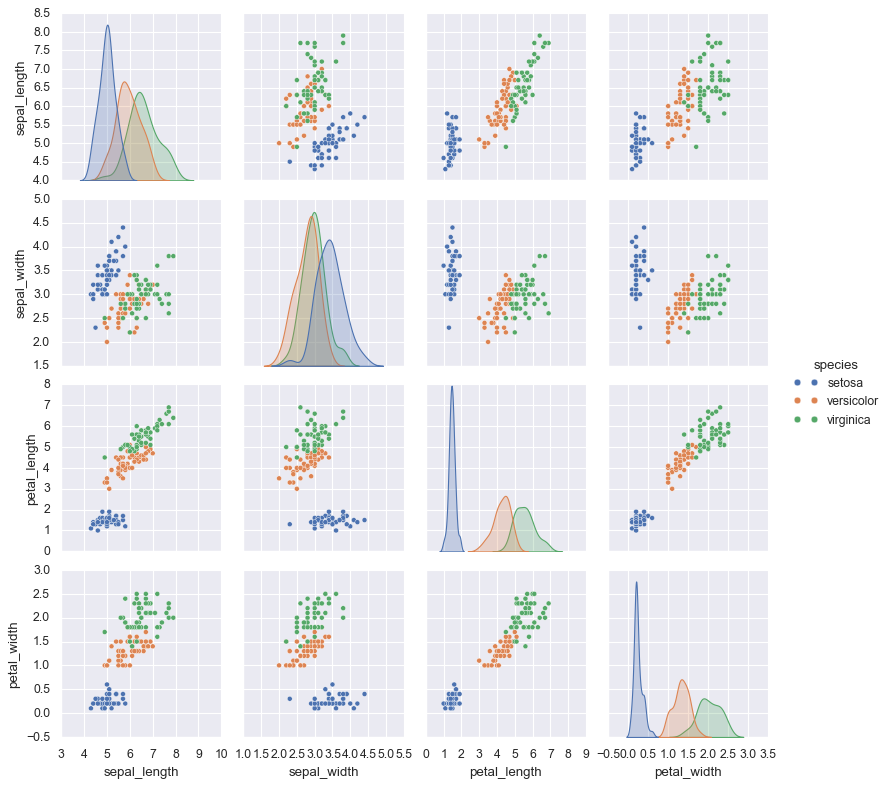

In [26]:
sns.pairplot(iris, hue='species', height=2.5); # 直接一句代码即可

#### 3. 分面频次直方图：按类别的直方图。 按类别分布

In [27]:
tips = sns.load_dataset('tips') 
tips.head() 

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


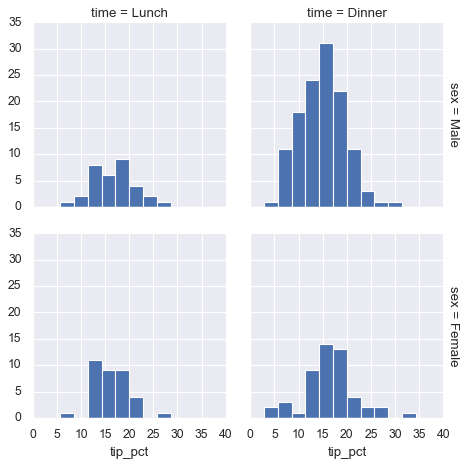

In [28]:
tips['tip_pct'] = 100 * tips['tip'] / tips['total_bill'] # 小费占总账单的百分比。
 
grid = sns.FacetGrid(tips, row="sex", col="time", margin_titles=True) # 用于根据指定的分类变量来拆分数据，并生成一个 面板（facet） 图。
grid.map(plt.hist, "tip_pct", bins=np.linspace(0, 40, 15)); 

#### 4. 箱线图： 分位点
- 箱体：Q1-Q3分位点. 四分位距`IQR = Q3 - Q1`
- 箱体里面横线：median
- 须：非异常范围。端点默认为`Q1 - 1.5 × IQR` 和 `Q3 + 1.5 × IQR`
- 单独点：异常值

`catplot` : categorical

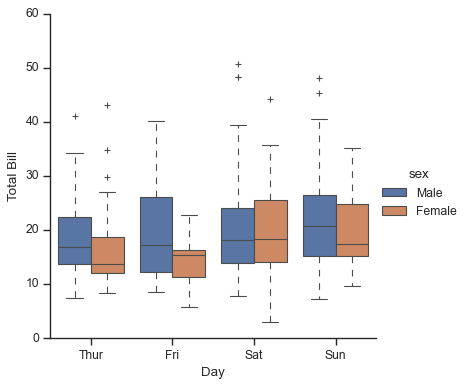

In [35]:
with sns.axes_style(style='ticks'): 
    g = sns.catplot(x="day", y="total_bill", hue="sex", data=tips, kind="box") 
    g.set_axis_labels("Day", "Total Bill")

#### 5. 联合分布

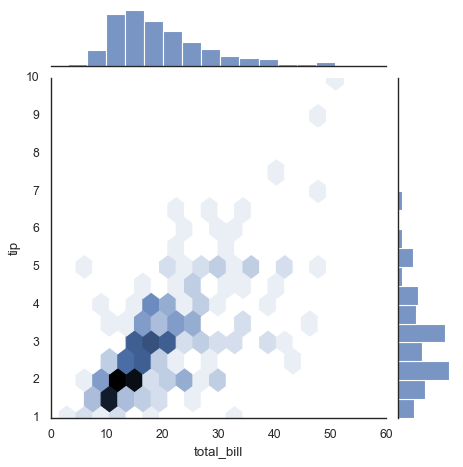

In [118]:
# 使用 jointplot 创建 hexbin 图
with sns.axes_style('white'): 
    sns.jointplot(x="total_bill", y="tip", data=tips, kind='hex')

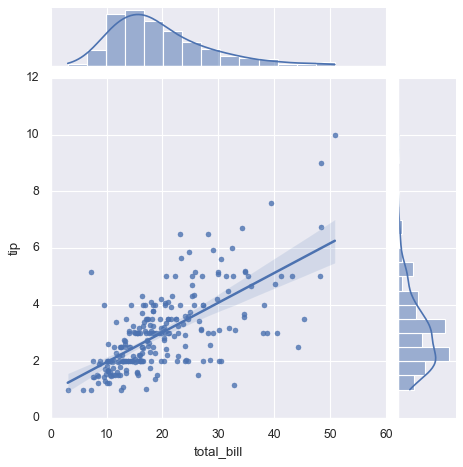

In [120]:
sns.jointplot(x="total_bill", y="tip", data=tips, kind='reg'); # 带回归拟合

#### 6. 条形图: 每个分类统计

In [30]:
planets = sns.load_dataset('planets') 
planets.head() 

,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.300,7.10,77.40,2006
1,Radial Velocity,1,874.774,2.21,56.95,2008
2,Radial Velocity,1,763.000,2.60,19.84,2011
3,Radial Velocity,1,326.030,19.40,110.62,2007
4,Radial Velocity,1,516.220,10.50,119.47,2009


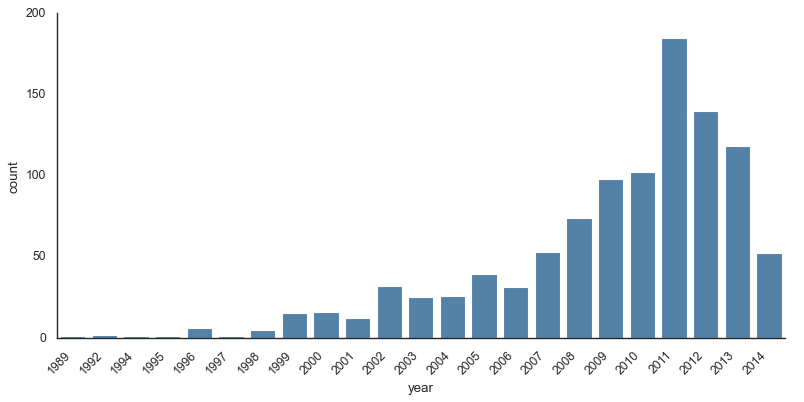

In [31]:
# 使用 catplot 创建计数图
with sns.axes_style('white'): 
    g = sns.catplot(x="year", data=planets, aspect=2,  #aspect控制宽度
                    kind="count", color='steelblue')
    # 设置 x 轴标签的步长
    g.set_xticklabels(rotation=45, ha="right")

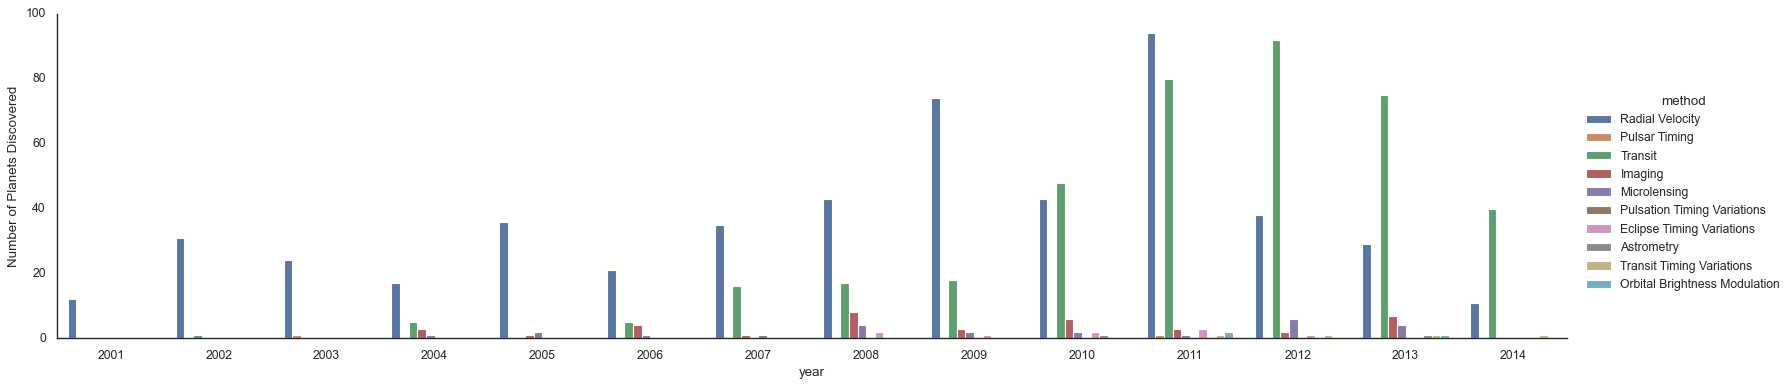

In [32]:
# 使用 catplot 创建计数图，根据method字段着色
with sns.axes_style('white'): 
    g = sns.catplot(x="year", data=planets, aspect=4.0, kind='count', 
                    hue='method', order=range(2001, 2015)) # 指定年份

    # 设置 y 轴标签
    g.set_ylabels('Number of Planets Discovered')


#### 7. 热图

In [1]:
# 生成 5x5 矩阵
mat = np.random.rand(5, 5)

# 绘制热图
sns.heatmap(mat, 
            square=True, 
            annot=True, 
            cbar=False,
            cmap="coolwarm",
            yticklabels = False
           ) # 正方形，显示数字，不显示colorbar

NameError: name 'np' is not defined

#### 7. 等高线

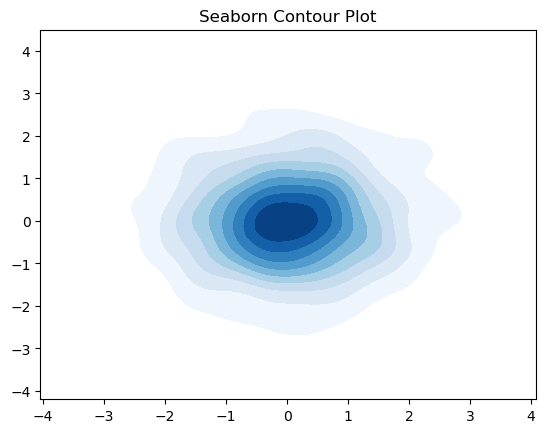

In [1]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# 生成数据
x = np.random.normal(size=1000)
y = np.random.normal(size=1000)

# 使用 seaborn 绘制等高线
sns.kdeplot(x=x, y=y, cmap='Blues', fill=True, thresh=0.05)
plt.title('Seaborn Contour Plot')
plt.show()


#### 8. 折线图

d:\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 36724 (\N{CJK UNIFIED IDEOGRAPH-8F74}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 31616 (\N{CJK UNIFIED IDEOGRAPH-7B80}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 21333 (\N{CJK UNIFIED IDEOGRAPH-5355}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 25240 (\N{CJK UNIFIED IDEOGRAPH-6298}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\minicon

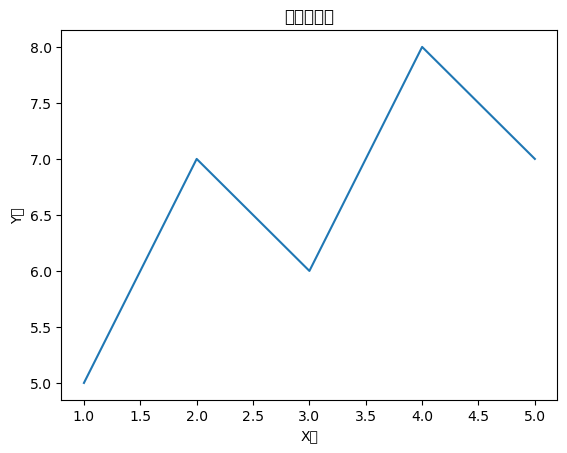

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# 示例数据
data = {
    'x': [1, 2, 3, 4, 5],
    'y': [5, 7, 6, 8, 7]
}

# 画折线图
sns.lineplot(x=data['x'], y=data['y'])

plt.title('简单折线图')
plt.xlabel('X轴')
plt.ylabel('Y轴')
plt.show()


### 4.16.3　案例：探索马拉松比赛成绩数据

In [127]:
data = pd.read_csv('marathon-data.csv') 
data.head() 

,age,gender,split,final
0,33,M,01:05:38,02:08:51
1,32,M,01:06:26,02:09:28
2,31,M,01:06:49,02:10:42
3,38,M,01:06:16,02:13:45
4,31,M,01:06:32,02:13:59


In [128]:
data.dtypes

age        int64
gender    object
split     object
final     object
dtype: object

默认情况下， 时间都会转为字符串对象，我们需要转换位时间类型

In [132]:
def convert_time(s):
    # 分割并转换时、分、秒为整数
    h, m, s = map(int, s.split(':'))  
    # 将时分秒转换为timedelta格式
    return pd.to_timedelta(f"{h}h {m}m {s}s")
data = pd.read_csv('marathon-data.csv', converters={'split':convert_time, 'final':convert_time})  # 导入时，就传入转换函数
data.head() 

,age,gender,split,final
0,33,M,0 days 01:05:38,0 days 02:08:51
1,32,M,0 days 01:06:26,0 days 02:09:28
2,31,M,0 days 01:06:49,0 days 02:10:42
3,38,M,0 days 01:06:16,0 days 02:13:45
4,31,M,0 days 01:06:32,0 days 02:13:59


In [133]:
data.dtypes

age                 int64
gender             object
split     timedelta64[ns]
final     timedelta64[ns]
dtype: object

In [134]:
data['split_sec'] = data['split'].astype(int) / 1E9 
data['final_sec'] = data['final'].astype(int) / 1E9 
data.head() 

,age,gender,split,final,split_sec,final_sec
0,33,M,0 days 01:05:38,0 days 02:08:51,3938.0,7731.0
1,32,M,0 days 01:06:26,0 days 02:09:28,3986.0,7768.0
2,31,M,0 days 01:06:49,0 days 02:10:42,4009.0,7842.0
3,38,M,0 days 01:06:16,0 days 02:13:45,3976.0,8025.0
4,31,M,0 days 01:06:32,0 days 02:13:59,3992.0,8039.0


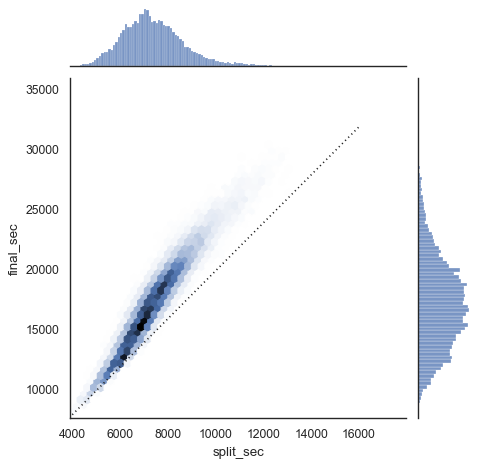

In [143]:
 with sns.axes_style('white'):
    g = sns.jointplot(x="split_sec", y="final_sec", data=data, kind='hex')
    g.ax_joint.plot(np.linspace(4000, 16000), np.linspace(8000, 32000), ':k') # 添加一条虚线： 

虚线表示这个人上半程时间和下半程时间一样。 但是显然，后半程更加耗时，越跑越慢。

现在衡量后半程加速的程度，小于0表示时后半程加速选手

In [145]:
data['split_frac'] = 1 - 2 * data['split_sec'] / data['final_sec'] 
data.head() 

,age,gender,split,final,split_sec,final_sec,split_frac
0,33,M,0 days 01:05:38,0 days 02:08:51,3938.0,7731.0,-0.018756
1,32,M,0 days 01:06:26,0 days 02:09:28,3986.0,7768.0,-0.026262
2,31,M,0 days 01:06:49,0 days 02:10:42,4009.0,7842.0,-0.022443
3,38,M,0 days 01:06:16,0 days 02:13:45,3976.0,8025.0,0.009097
4,31,M,0 days 01:06:32,0 days 02:13:59,3992.0,8039.0,0.006842


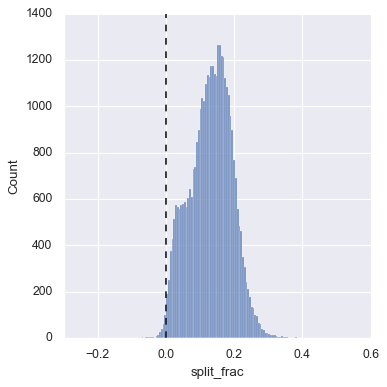

In [147]:
sns.displot(data['split_frac'], kde=False); 
plt.axvline(0, color="k", linestyle="--");

In [148]:
sum(data.split_frac < 0) 

251

可以看到，4万名仅仅有250名时后半程加速选手。

那探究这与其他变量是否有相关性

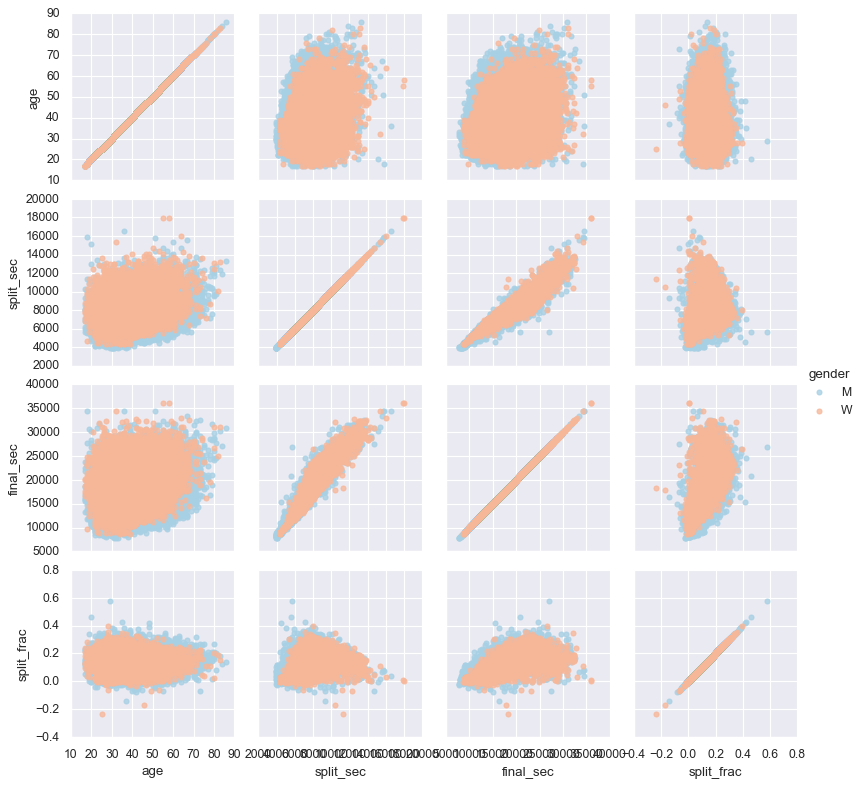

In [149]:
g = sns.PairGrid(data, vars=['age', 'split_sec', 'final_sec', 'split_frac'], 
                 hue='gender', palette='RdBu_r')  # pairplot自由版
g.map(plt.scatter, alpha=0.8) 
g.add_legend();

没看出什么相关性

对比男女选手差异：

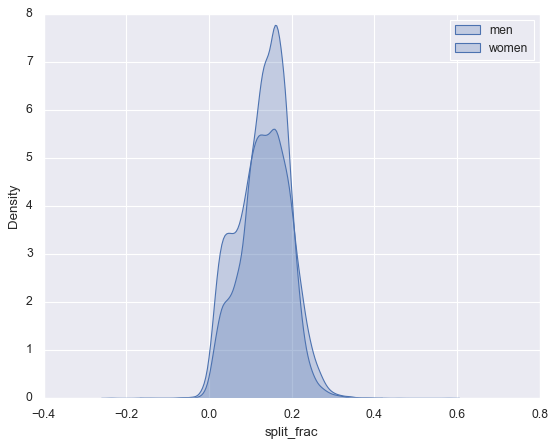

In [164]:
sns.kdeplot(data.split_frac[data.gender=='M'], label='men', fill=True) 
sns.kdeplot(data.split_frac[data.gender=='W'], label='women', fill=True) 
plt.legend()

男女的后半程加速系数 几乎都是双峰分布

分开来看

<Axes: xlabel='gender', ylabel='split_frac'>

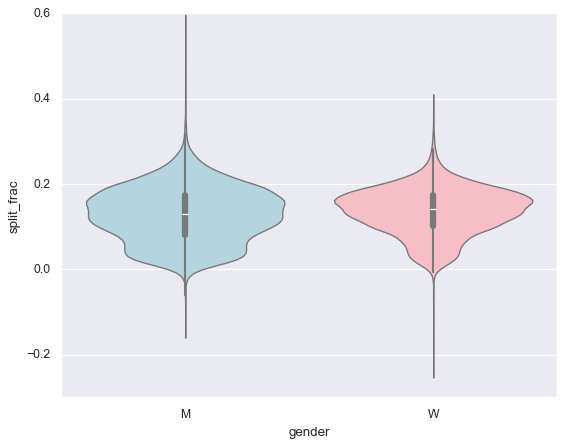

In [168]:
sns.violinplot(x="gender", y="split_frac", hue="gender", data=data, 
               palette=["lightblue", "lightpink"], legend=False)

通过年龄段再看看

In [167]:
data['age_dec'] = data.age.map(lambda age: 10 * (age // 10)) 
data.head() 

,age,gender,split,final,split_sec,final_sec,split_frac,age_dec
0,33,M,0 days 01:05:38,0 days 02:08:51,3938.0,7731.0,-0.018756,30
1,32,M,0 days 01:06:26,0 days 02:09:28,3986.0,7768.0,-0.026262,30
2,31,M,0 days 01:06:49,0 days 02:10:42,4009.0,7842.0,-0.022443,30
3,38,M,0 days 01:06:16,0 days 02:13:45,3976.0,8025.0,0.009097,30
4,31,M,0 days 01:06:32,0 days 02:13:59,3992.0,8039.0,0.006842,30


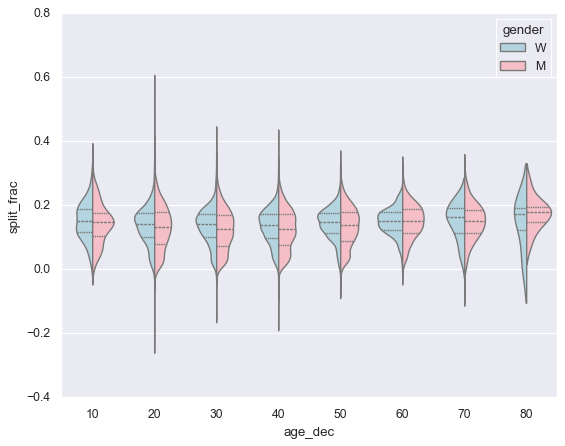

In [174]:
men = (data.gender == 'M') 
women = (data.gender == 'W') 

with sns.axes_style(style=None): 
    sns.violinplot(x="age_dec", y="split_frac", hue="gender", data=data, split=True, inner="quartile", 
                   palette=["lightblue", "lightpink"], legend=True)

可以看到 20-50岁，男性选手 后半程加速系数的分布 更加松散。 80以上的女选手发挥比80以上男选手发挥好得多

In [175]:
(data.age > 80).sum() 

np.int64(7)

这是因为80以上样本太少了

观察是哪些选手的 后半程加速系数 小于0

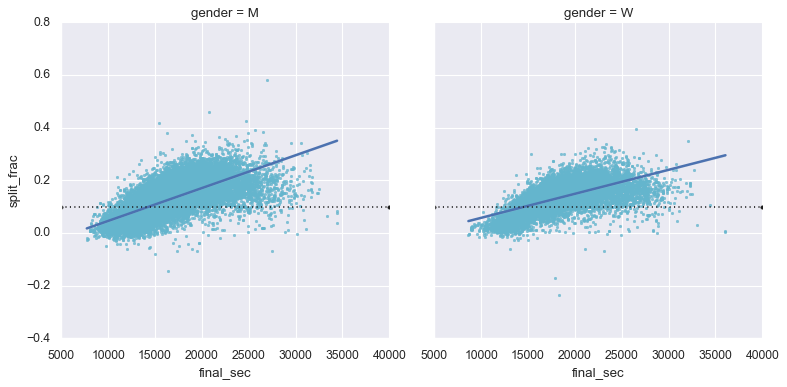

In [179]:
# Lmplot绘制散点图，并拟合直线。  col表示根据gender划分两个子图，
g = sns.lmplot(x='final_sec',y= 'split_frac', col='gender', data=data, 
                       markers=".", scatter_kws=dict(color='c')) 
g.map(plt.axhline, y=0.1, color="k", ls=":");

发现后半程加速选手的成绩都在15000秒内。

## 4.17 Animation动画

## 4.18 绘制线

In [1]:
ax.vlines(
    alpha_aic, # 垂直线X坐标
    results["AIC criterion"].min(), # y起始
    results["AIC criterion"].max(), # y结束
    label="alpha: AIC estimate", # 设置标签，自动图例
    linestyles="--",
    color="tab:blue",


SyntaxError: incomplete input (333518576.py, line 7)

## 4.19 茎叶图（stem plot）
绘制脉冲信号。 常常用于稀疏系数，大多数为0

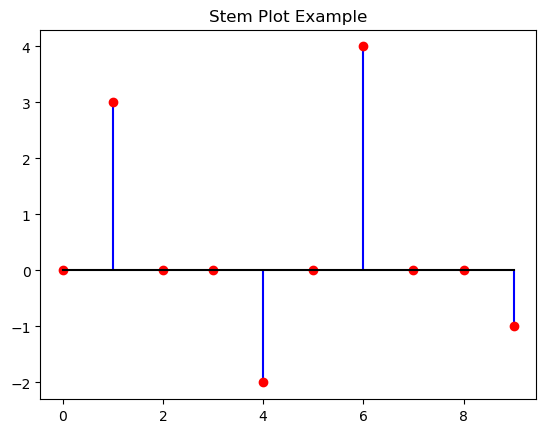

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 生成稀疏数据（大部分是 0）
x = np.arange(10)
y = np.array([0, 3, 0, 0, -2, 0, 4, 0, 0, -1])

# 画茎叶图
plt.stem(x, y, linefmt="b-", markerfmt="ro", basefmt="k-")
plt.title("Stem Plot Example")
plt.show()


## 4.20 patches补丁图形

### Ellipse 椭圆形

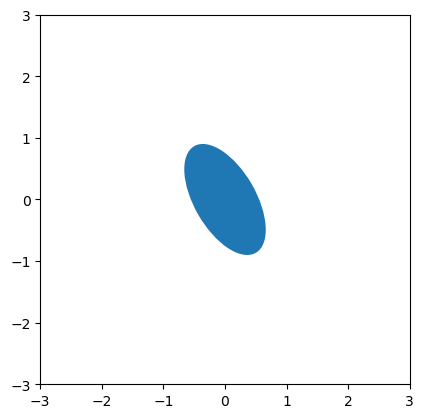

In [5]:
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
ellipsis = Ellipse(
    xy=(0, 0),
    width=1,
    height=2,
    angle=30,
)
fig, ax = plt.subplots()
ax.add_patch(ellipsis)
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_aspect('equal')

### 示例1： 绘制二维高斯分布的等高线

eigen val:  [1.38196601 3.61803399] angle:  -148.282525588539


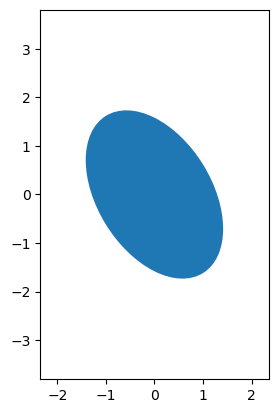

In [28]:
from matplotlib.patches import Ellipse
import matplotlib.pyplot as plt
import numpy as np
cov = np.array([
    [3, 1],
    [1, 2]
])
vals, vecs = np.linalg.eigh(cov)
angle = np.degrees(np.arctan2(*vecs[:, 1][::-1]))
width, height = 2 * np.sqrt(vals) #
e = Ellipse(
    xy=(0,0),
    width= width,
    height= height,
    angle= angle,
)
print('eigen val: ', vals, 'angle: ', angle)
fig, ax = plt.subplots()
ax.add_patch(e)
ax.set_xlim(-width, width)
ax.set_ylim(-height, height)
ax.set_aspect('equal')

## 4.21 颜色
https://matplotlib.org/stable/users/explain/colors/index.html
- 基础颜色直接指定： 'red' , 'r', (0.1, 0.2, 0.3), '#1f77b4'
- colormap把`[0,1]`的数值映射为颜色
- 其他内置调色板：如tableau `'tab:green'`

In [6]:
# 返回所有调色板
import matplotlib.pyplot as plt
plt.colormaps()

['magma',
 'inferno',
 'plasma',
 'viridis',
 'cividis',
 'twilight',
 'twilight_shifted',
 'turbo',
 'Blues',
 'BrBG',
 'BuGn',
 'BuPu',
 'CMRmap',
 'GnBu',
 'Greens',
 'Greys',
 'OrRd',
 'Oranges',
 'PRGn',
 'PiYG',
 'PuBu',
 'PuBuGn',
 'PuOr',
 'PuRd',
 'Purples',
 'RdBu',
 'RdGy',
 'RdPu',
 'RdYlBu',
 'RdYlGn',
 'Reds',
 'Spectral',
 'Wistia',
 'YlGn',
 'YlGnBu',
 'YlOrBr',
 'YlOrRd',
 'afmhot',
 'autumn',
 'binary',
 'bone',
 'brg',
 'bwr',
 'cool',
 'coolwarm',
 'copper',
 'cubehelix',
 'flag',
 'gist_earth',
 'gist_gray',
 'gist_heat',
 'gist_ncar',
 'gist_rainbow',
 'gist_stern',
 'gist_yarg',
 'gnuplot',
 'gnuplot2',
 'gray',
 'hot',
 'hsv',
 'jet',
 'nipy_spectral',
 'ocean',
 'pink',
 'prism',
 'rainbow',
 'seismic',
 'spring',
 'summer',
 'terrain',
 'winter',
 'Accent',
 'Dark2',
 'Paired',
 'Pastel1',
 'Pastel2',
 'Set1',
 'Set2',
 'Set3',
 'tab10',
 'tab20',
 'tab20b',
 'tab20c',
 'grey',
 'gist_grey',
 'gist_yerg',
 'Grays',
 'magma_r',
 'inferno_r',
 'plasma_r',
 'viri

### 调色板分类：
- 单色渐变: 'viridis'; 密度，连续值
- 正负变化：'coolwarm'; 残差
- 离散分类：'tab10'; 多酚类
- 特殊：'flag'；周期 特效数据

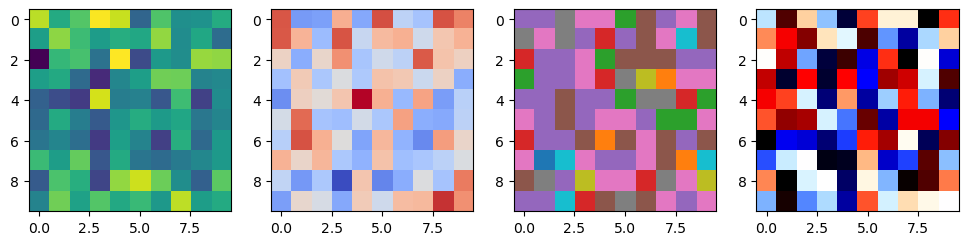

In [22]:
fig, axes = plt.subplots(1, 4, figsize = (12, 3))
rng = np.random.RandomState(0)
axes[0].imshow(rng.randn(10,10), cmap='viridis')
axes[1].imshow(rng.randn(10,10), cmap='coolwarm')
axes[2].imshow(rng.randn(10,10), cmap='tab10')
axes[3].imshow(rng.randn(10,10), cmap='flag')


### colors接口

In [17]:
from matplotlib import colors

解析到标准RGB

In [18]:
colors.to_rgb('tab:green')

(0.17254901960784313, 0.6274509803921569, 0.17254901960784313)

In [19]:
colors.to_rgba('#ff0000', alpha=0.5)

(1.0, 0.0, 0.0, 0.5)

数值映射到[0,1]， 

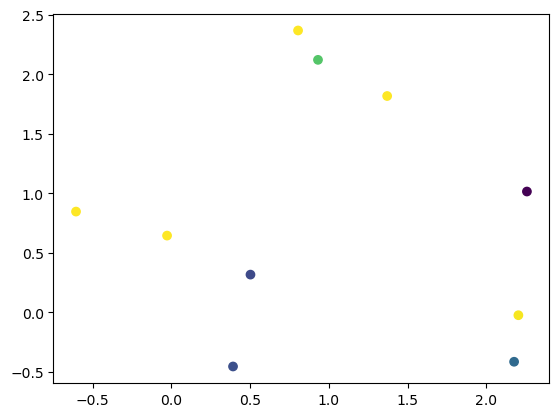

In [20]:
X = np.random.randn(10, 3) + 1
norm = colors.Normalize(vmin=0, vmax=1)
plt.scatter(X[:,0], X[:, 1], c=X[:, 2], norm=norm) # 必须携带c参数

颜色表

In [21]:
colors.TABLEAU_COLORS

{'tab:blue': '#1f77b4',
 'tab:orange': '#ff7f0e',
 'tab:green': '#2ca02c',
 'tab:red': '#d62728',
 'tab:purple': '#9467bd',
 'tab:brown': '#8c564b',
 'tab:pink': '#e377c2',
 'tab:gray': '#7f7f7f',
 'tab:olive': '#bcbd22',
 'tab:cyan': '#17becf'}

### cm接口: 方便直接取色

In [24]:
from matplotlib import colormaps

In [27]:
# 获取colormap对象 调色板
cmap = colormaps.get_cmap('viridis')

In [28]:
cmap(0.5) # cmap可以直接调用，将[0,1]映射到RGB

(np.float64(0.127568),
 np.float64(0.566949),
 np.float64(0.550556),
 np.float64(1.0))

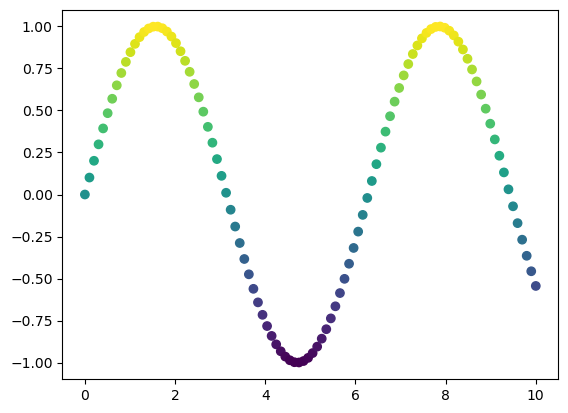

In [31]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import colormaps

x = np.linspace(0, 10, 100)
y = np.sin(x)
colors = colormaps.get_cmap('viridis')((y - y.min()) / (y.max() - y.min()))

plt.scatter(x, y, color=colors)
plt.show()


### facecolor 填充色, edgecolor

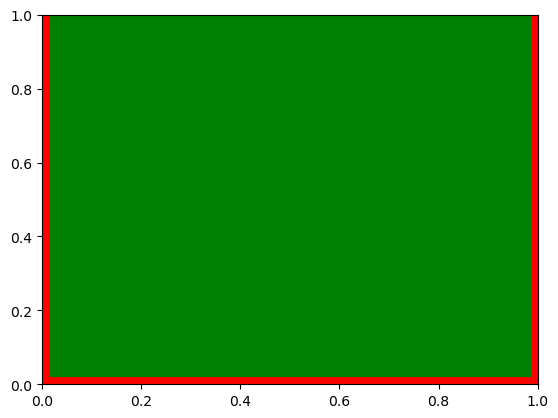

In [28]:
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
rect = Rectangle((0,0), 1, 2, facecolor='green', edgecolor='red', linewidth=10)  # 填充绿色
ax.add_patch(rect)
plt.show()


## 4.23 线条lines


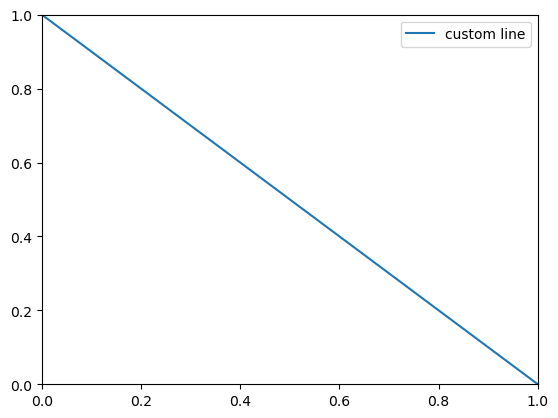

In [6]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
line = mlines.Line2D(
    [0, 1], [1, 0], # 线段起点终点
    label = 'custom line'
)
fig, ax = plt.subplots()
ax.add_line(line)
ax.legend()

示例：自定义legend    
[] 不会画线，只有符号

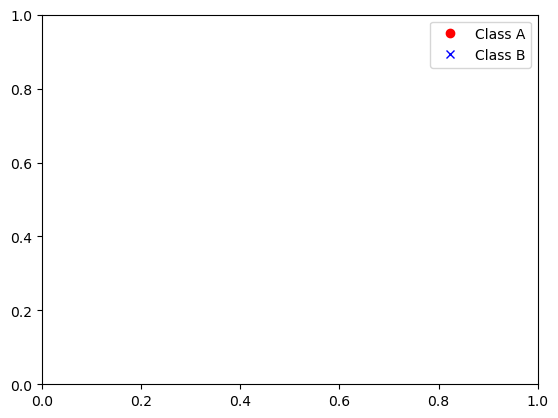

In [8]:
import matplotlib.lines as mlines

lineA = mlines.Line2D([], [], color='red', marker='o', linestyle='None', label='Class A')
lineB = mlines.Line2D([], [], color='blue', marker='x', linestyle='None', label='Class B')

plt.legend(handles=[lineA, lineB])
